# <center> **Функции нескольких переменных**

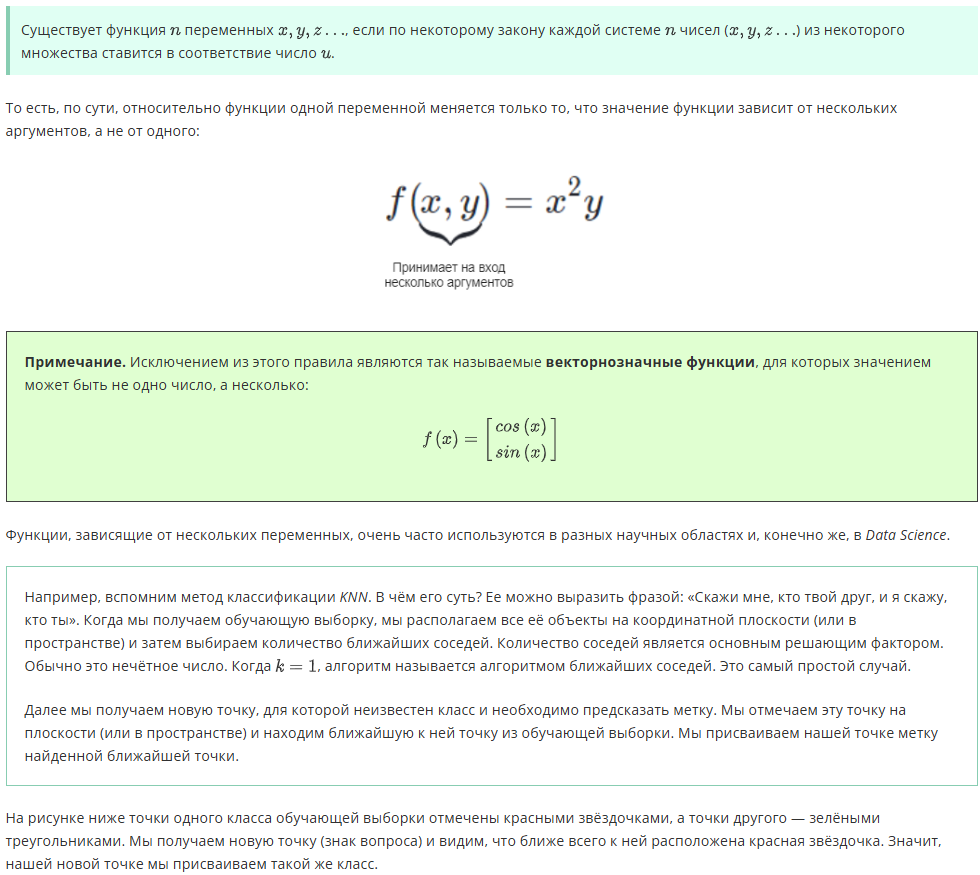

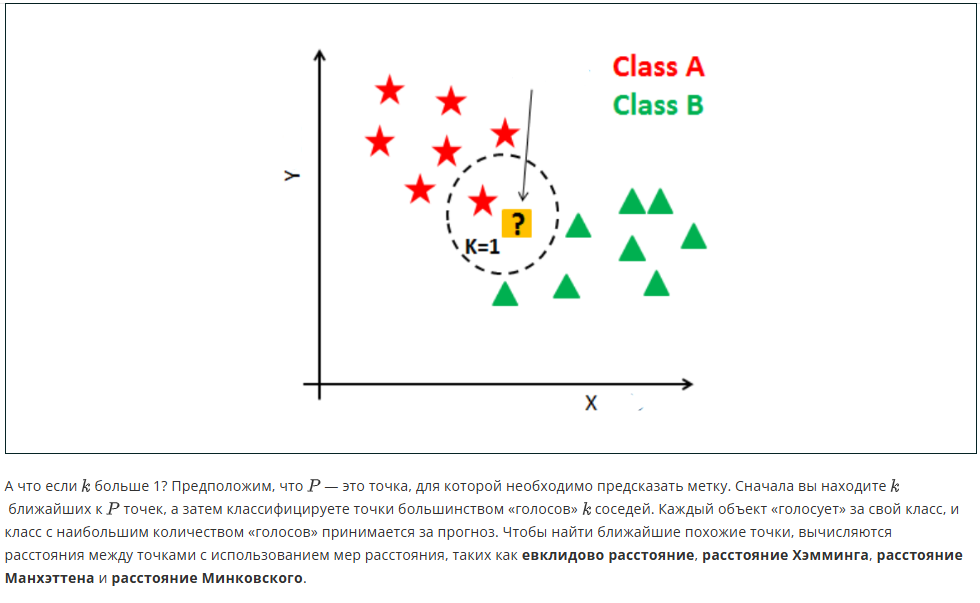

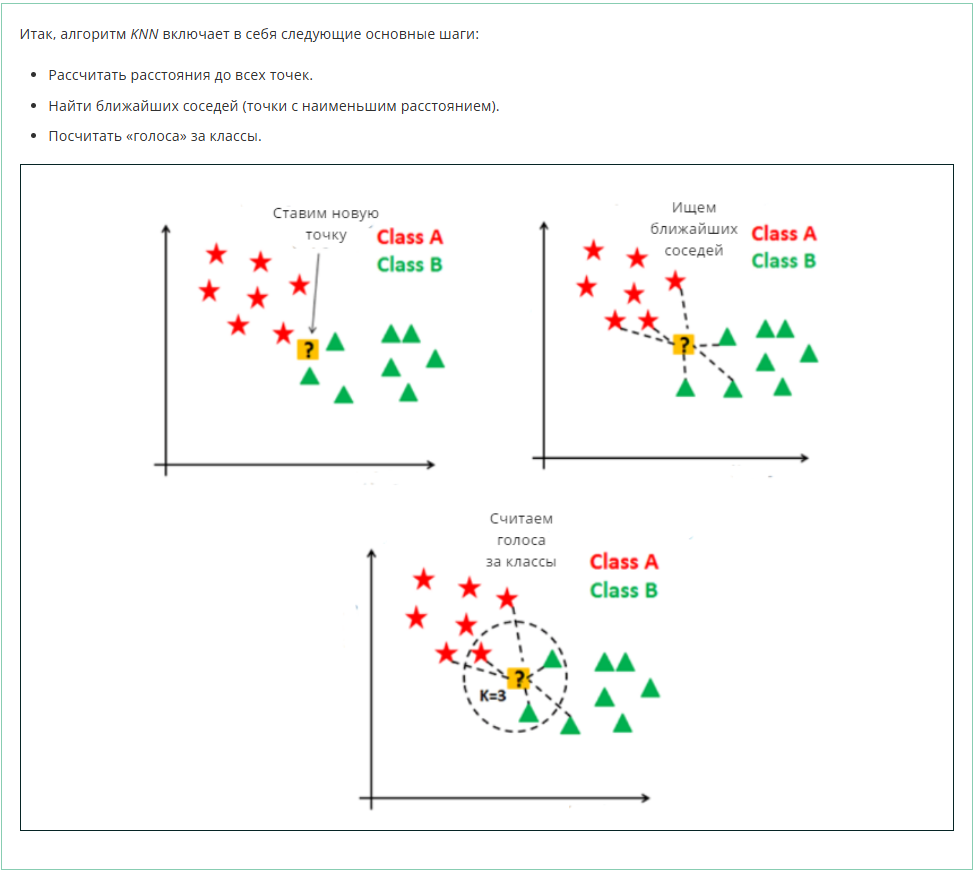

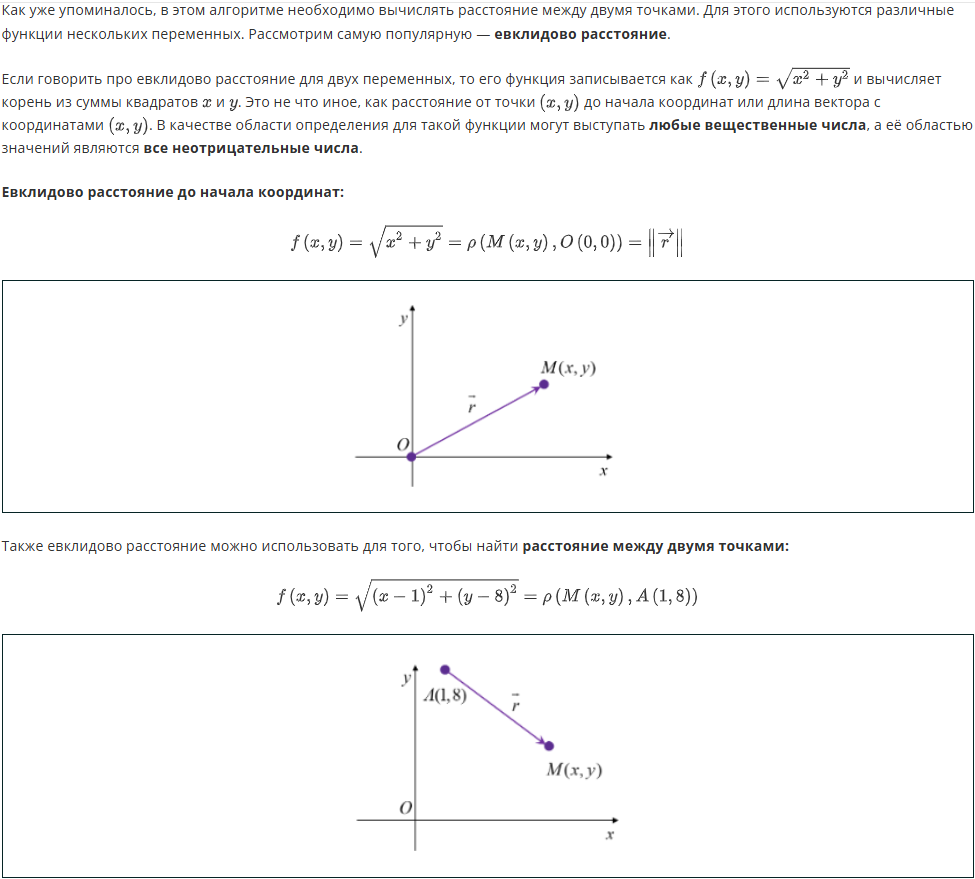

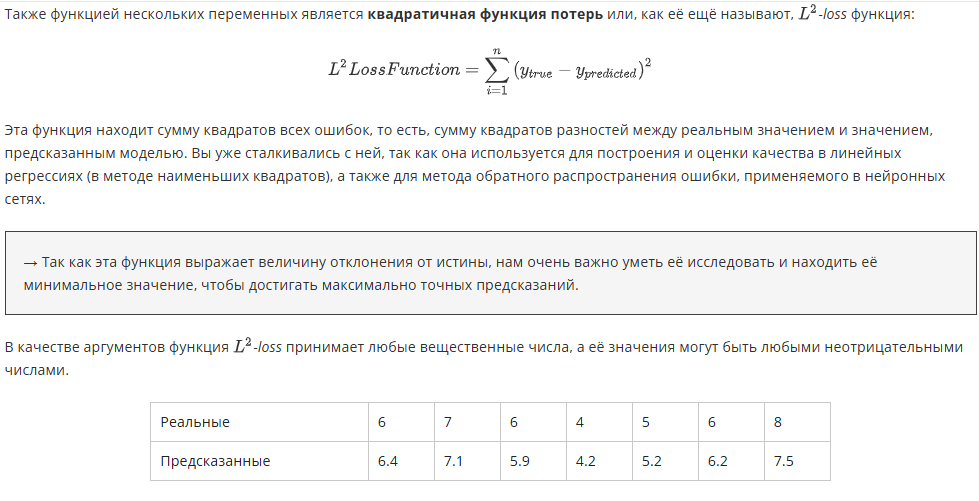

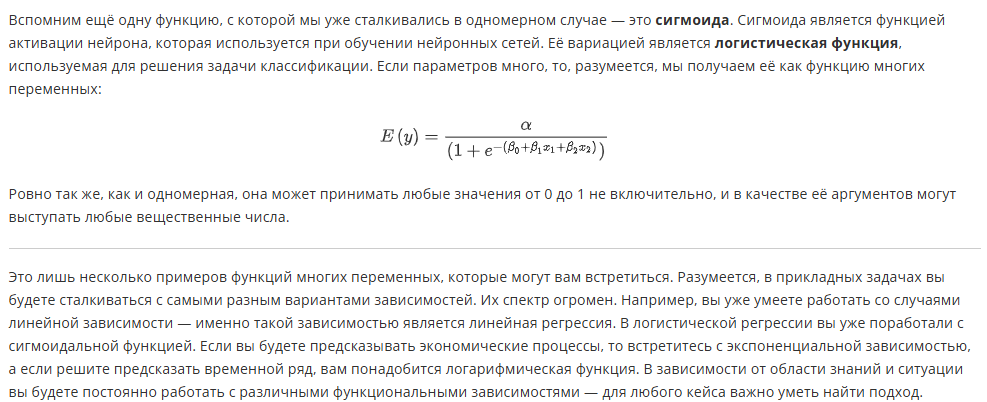

# Частные производные

>Производные для функций нескольких переменных называются **частными производными**.

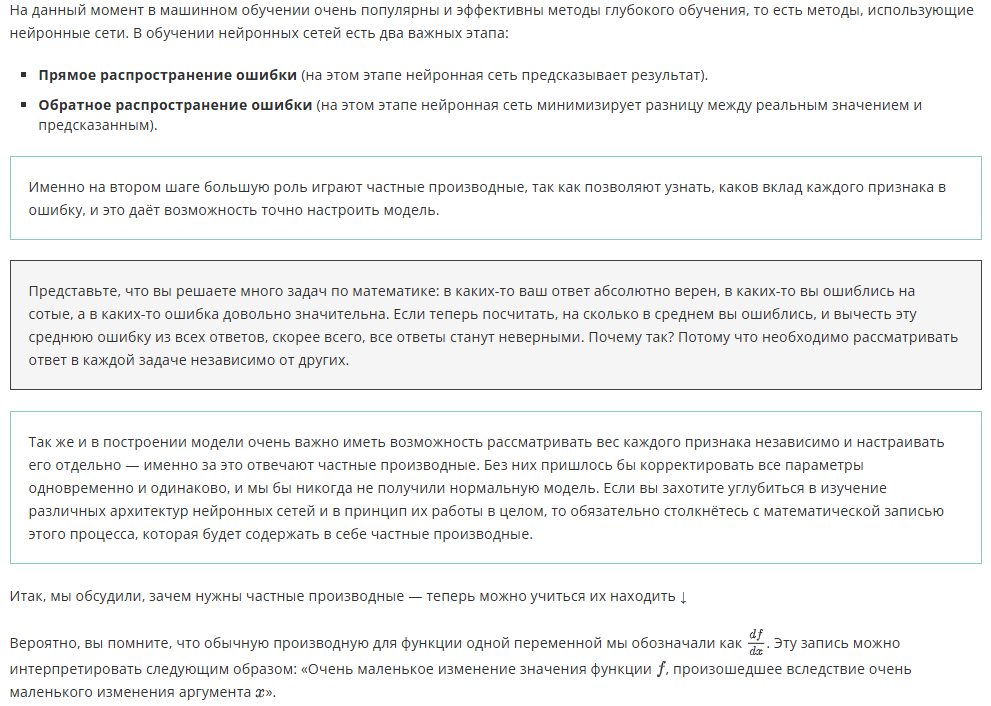

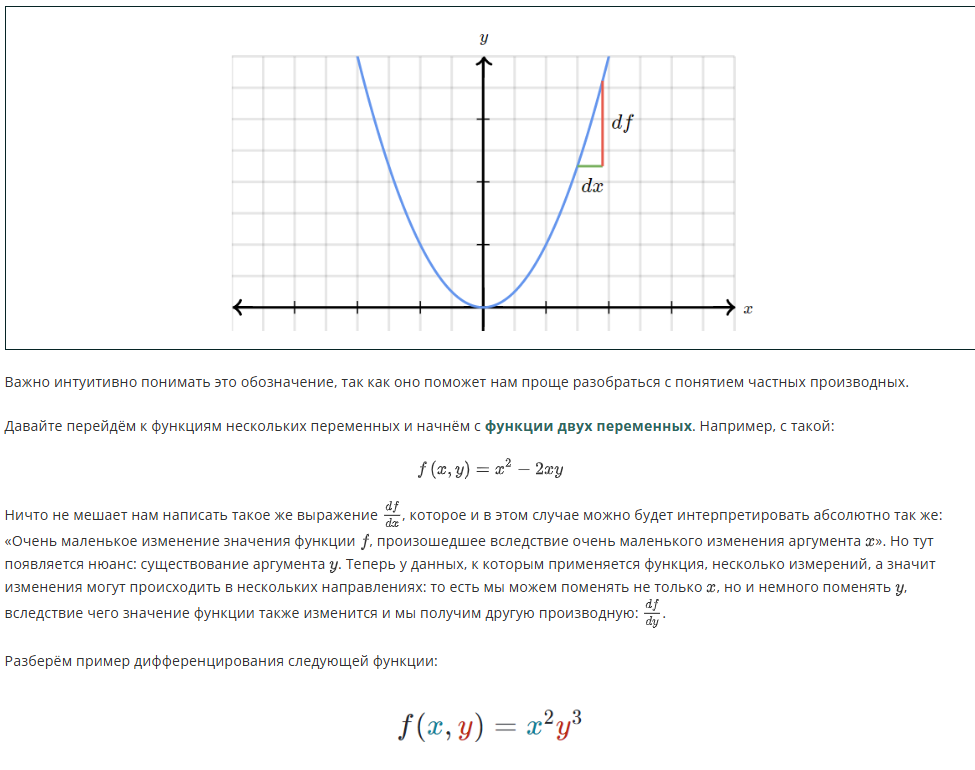

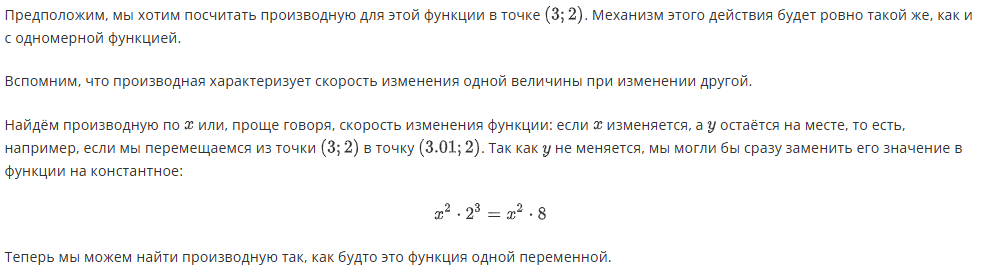

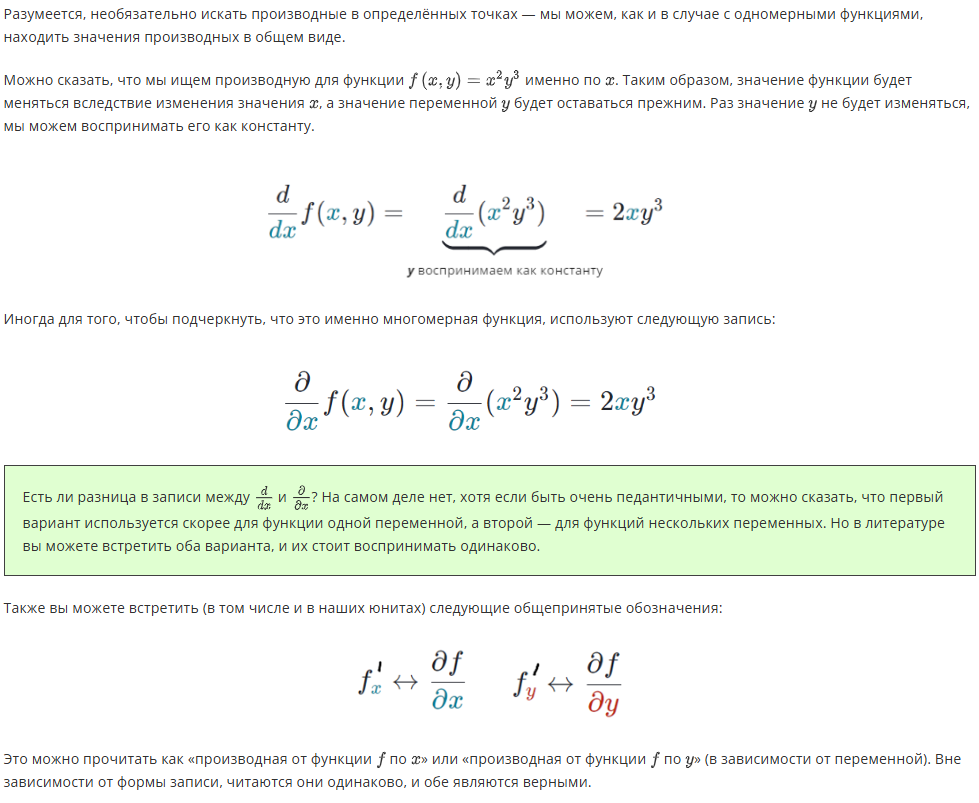

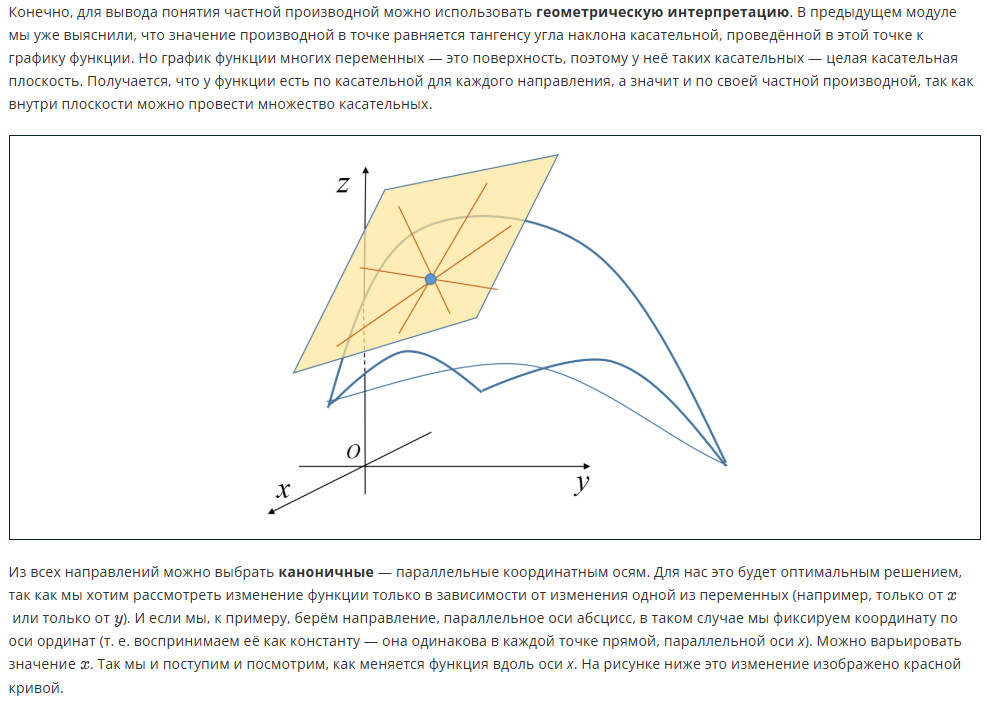

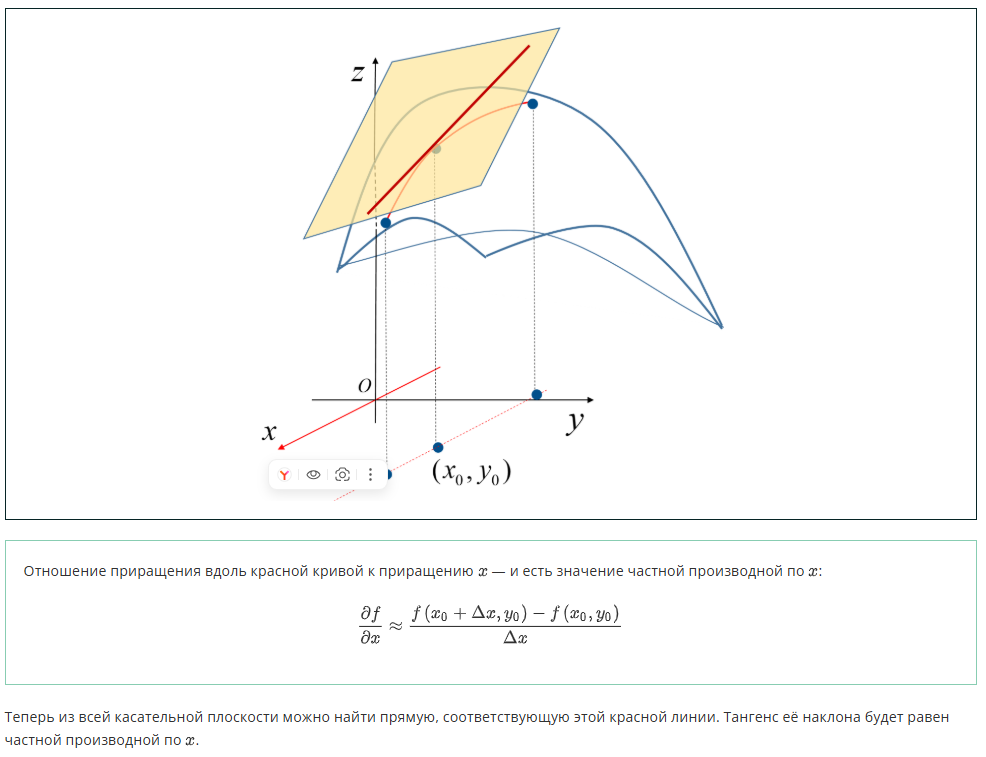

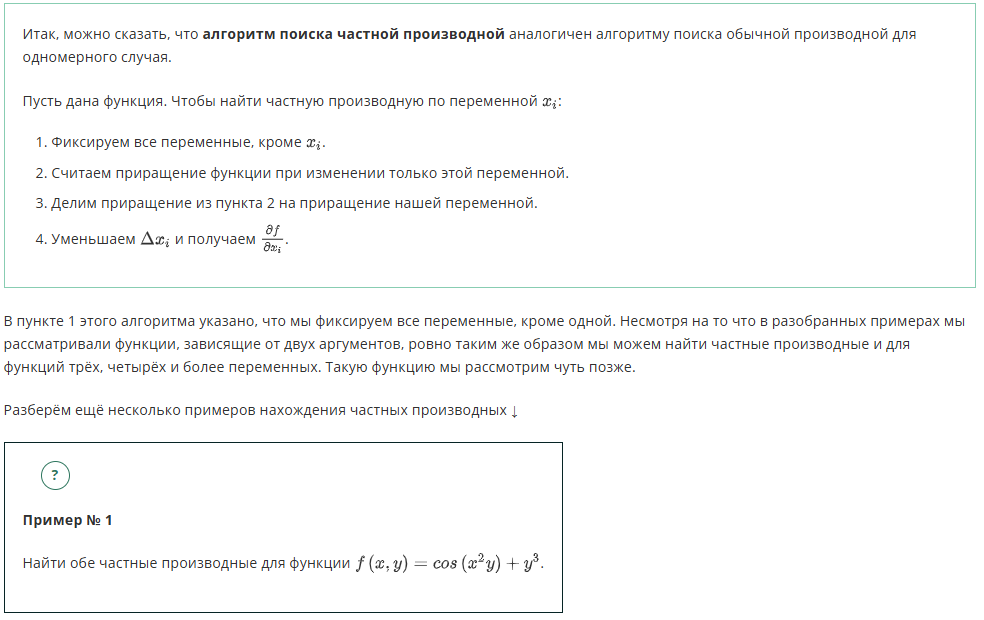

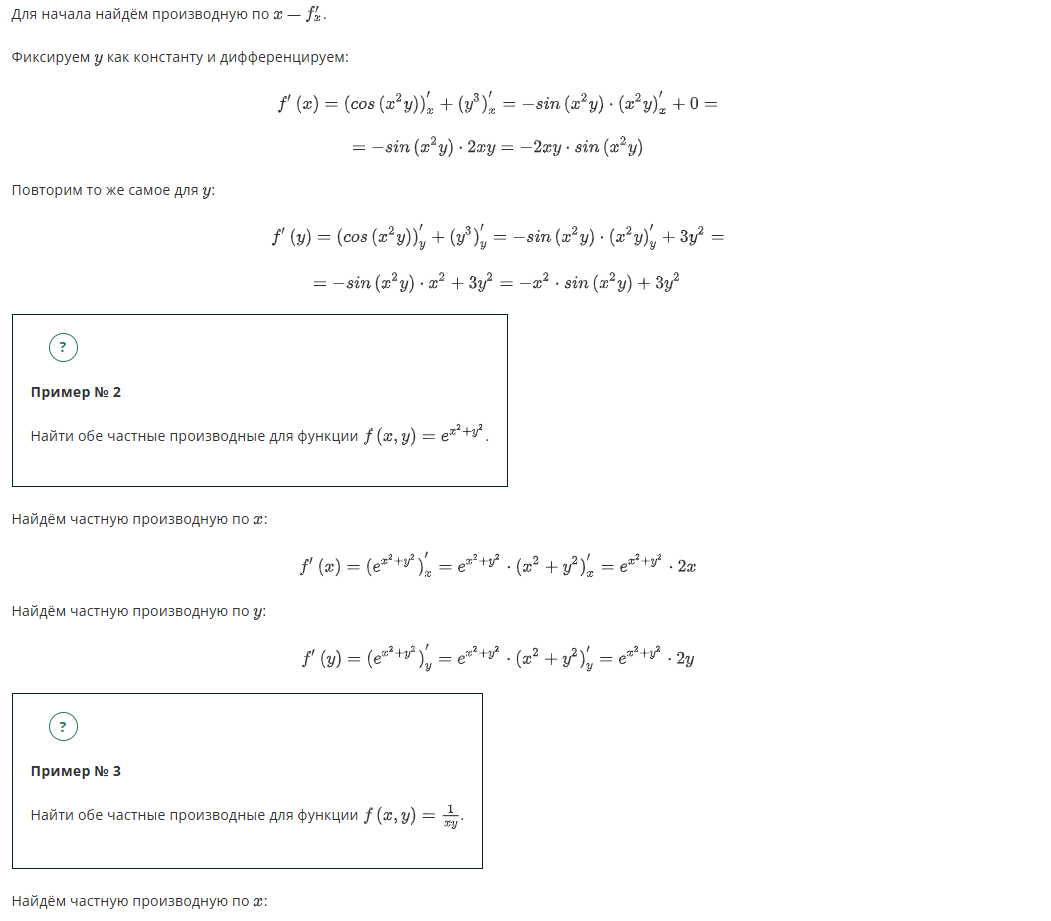

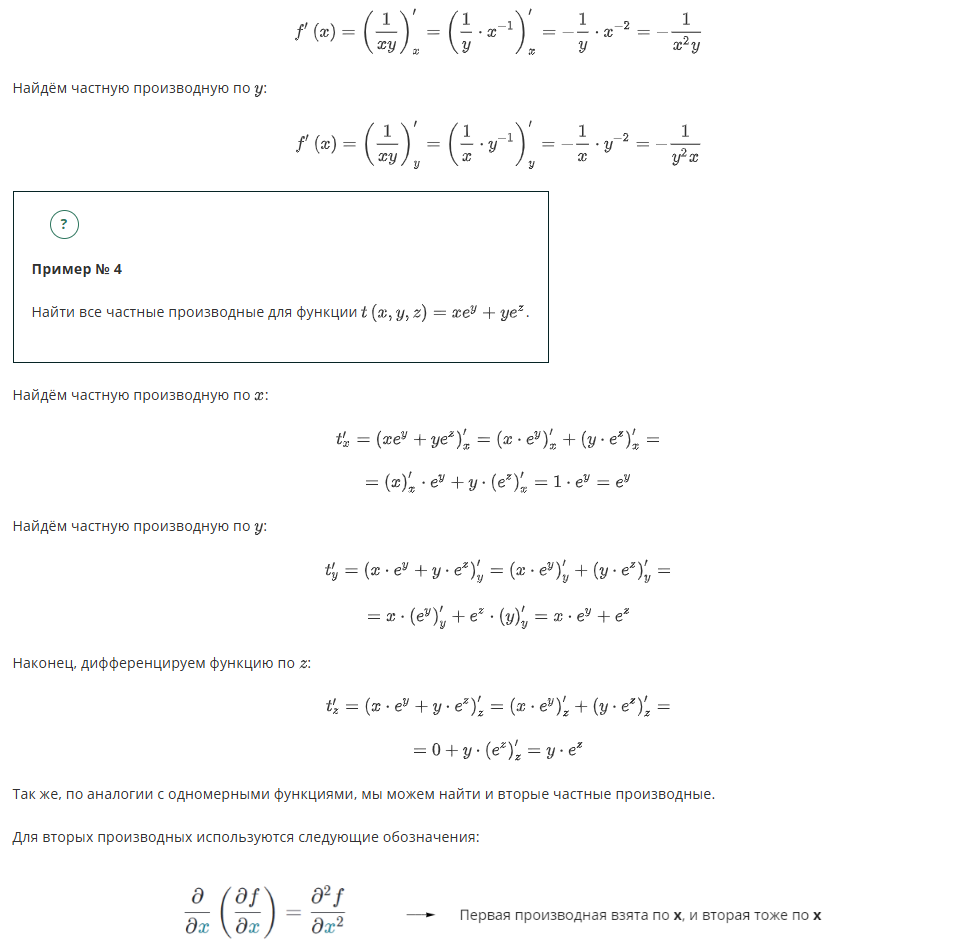

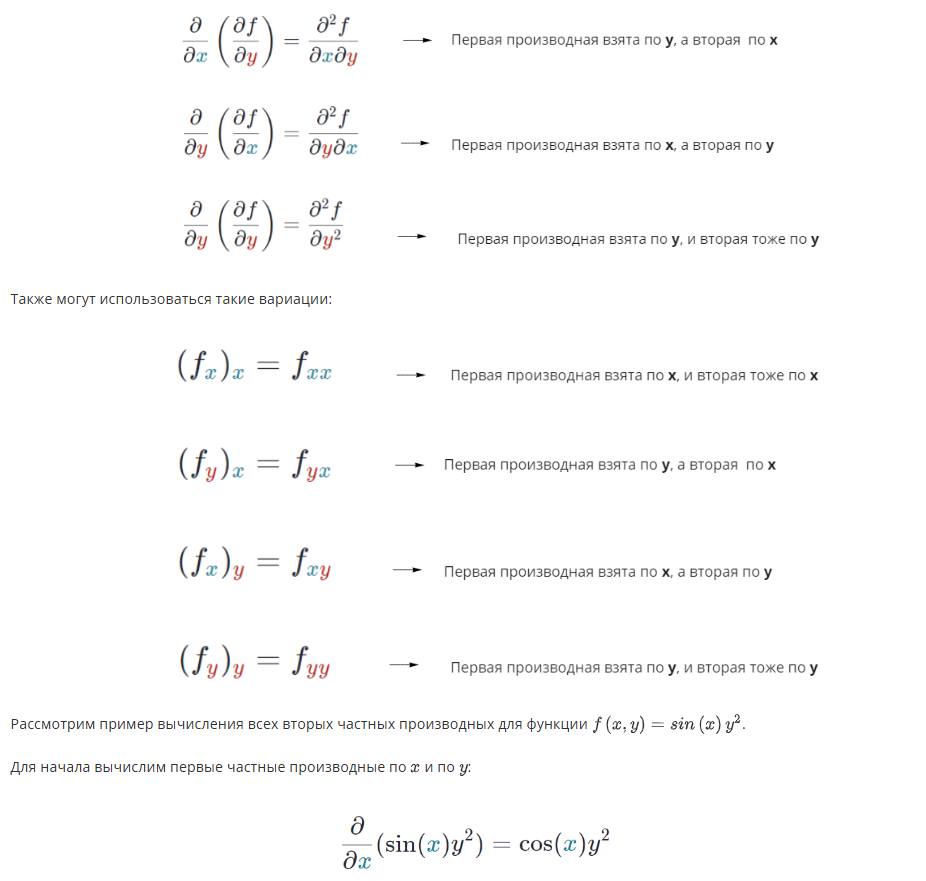

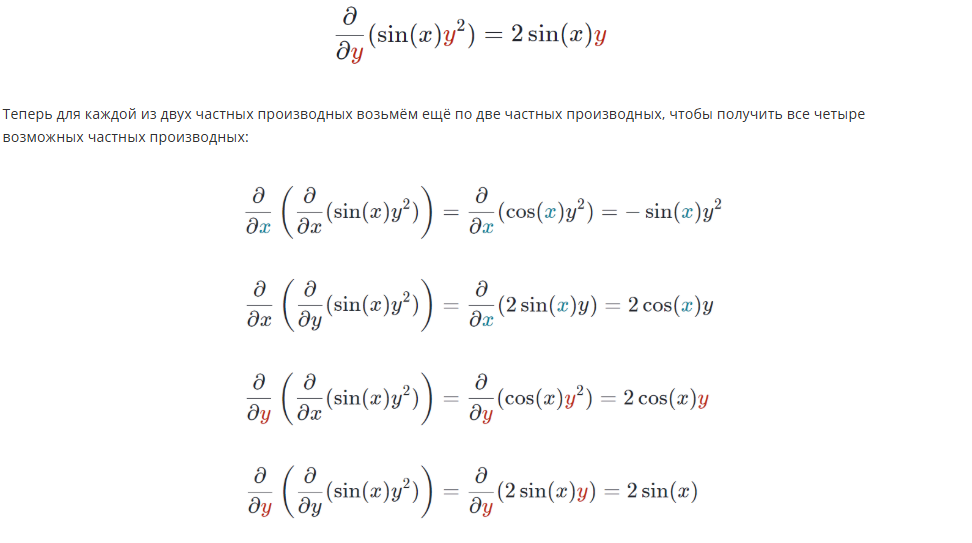

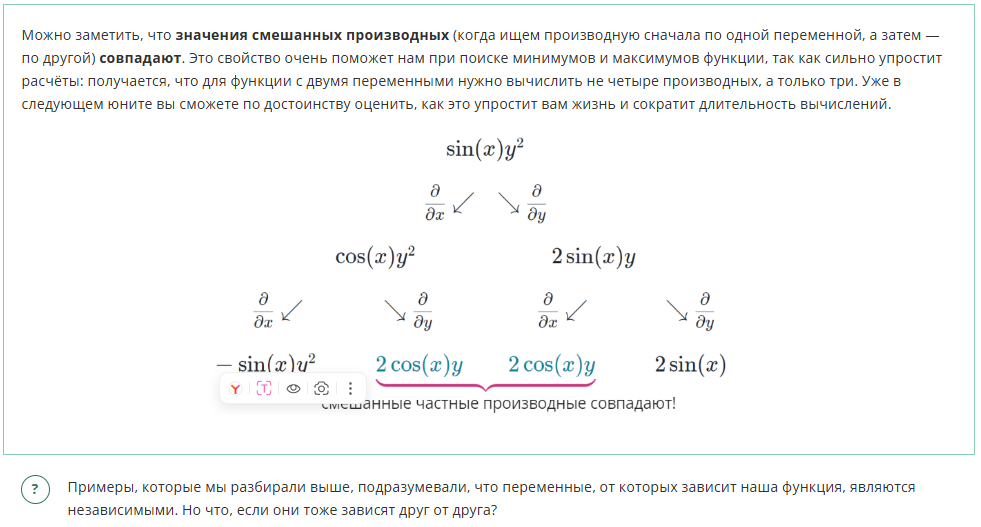

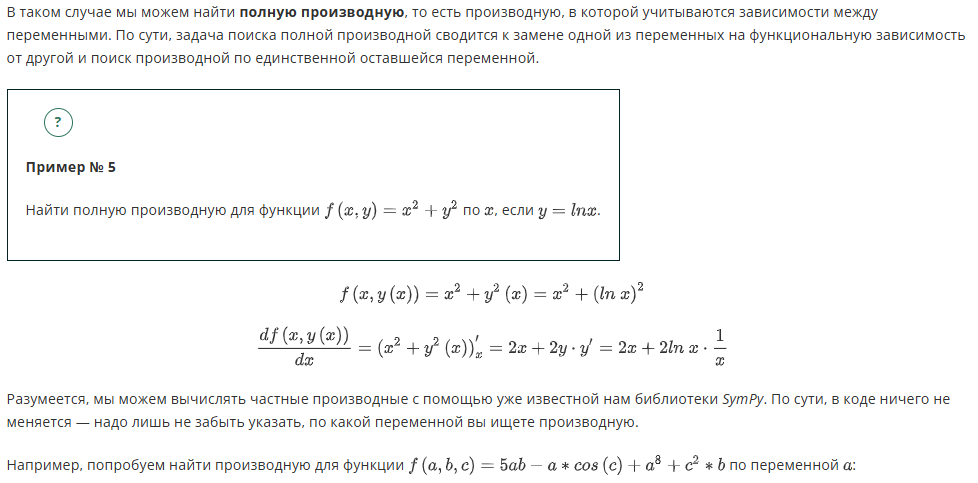

In [9]:
from sympy import symbols, cos, diff

a, b, c = symbols('a b c', real=True)
f = 5*a*b - a*cos(c) + a**8 + c**2*b

print(diff(f, a))

8*a**7 + 5*b - cos(c)


# Безусловные экстремумы. Функции нескольких переменных

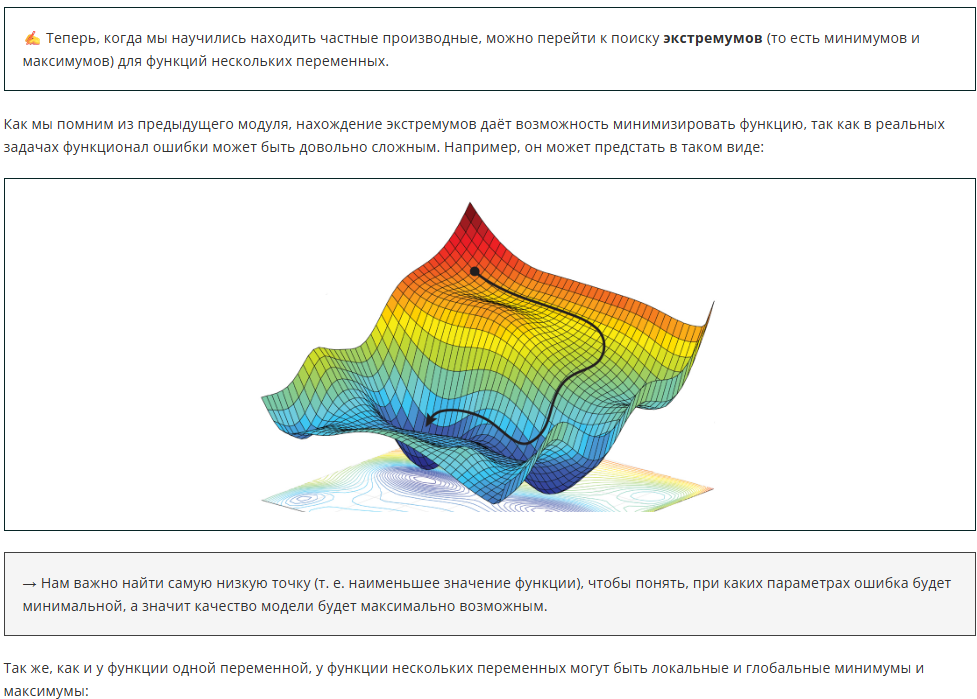

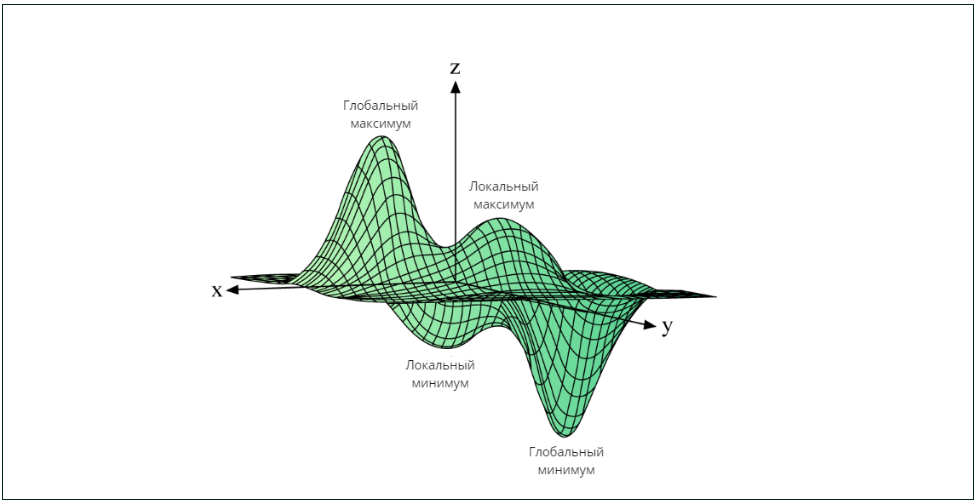

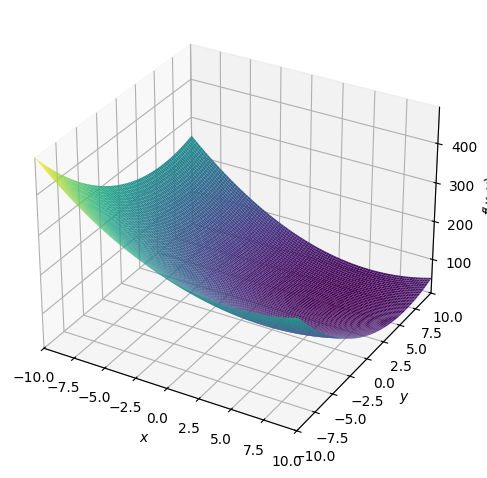

In [10]:
from sympy import *
from sympy.plotting import plot3d

x, y = symbols('x y')
f=x**2 - 10 * x + y**2 - 12 * y + 71
plot3d(f)

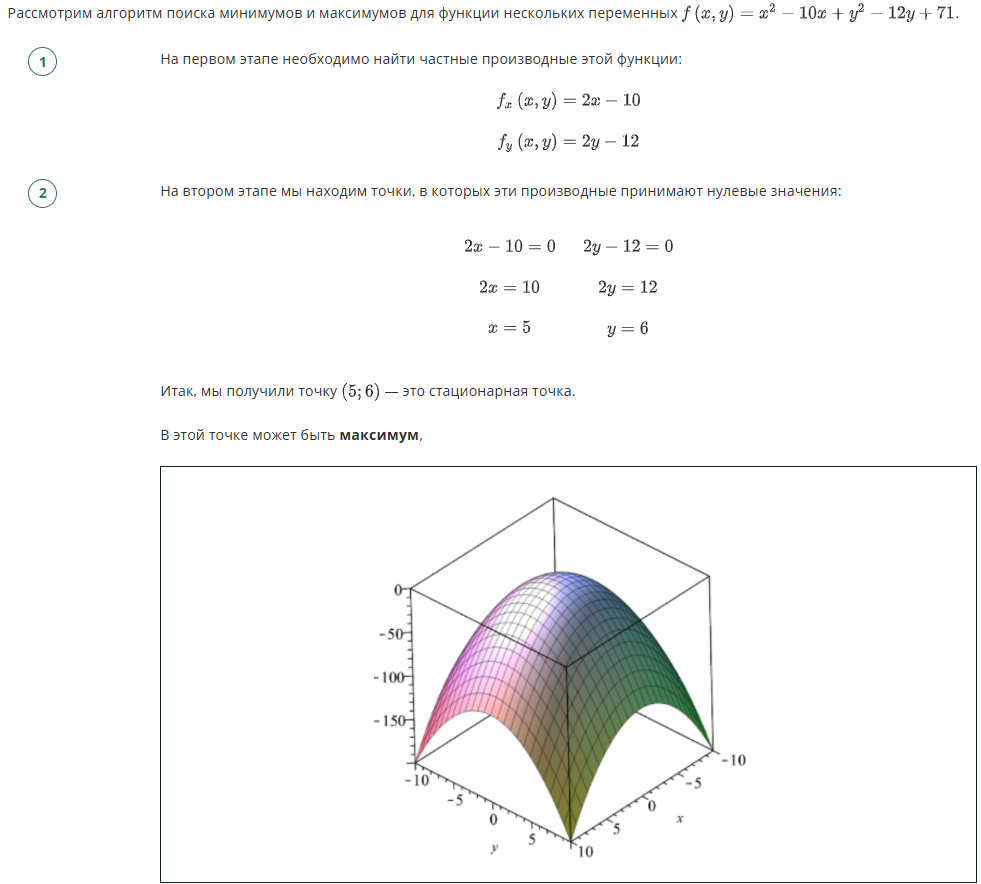

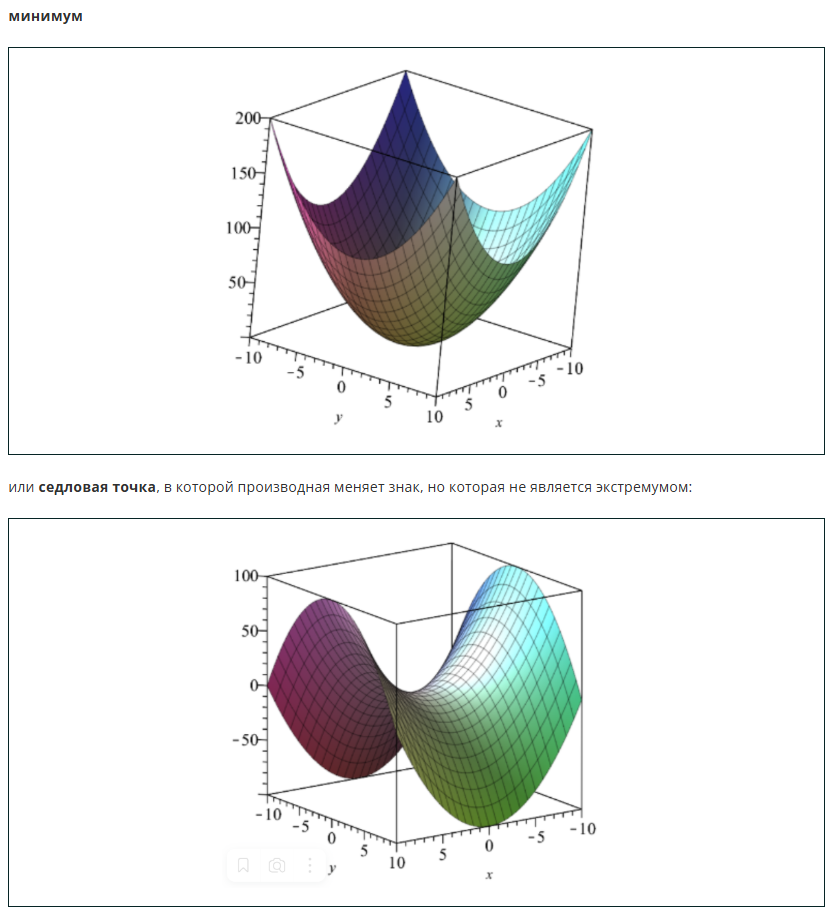

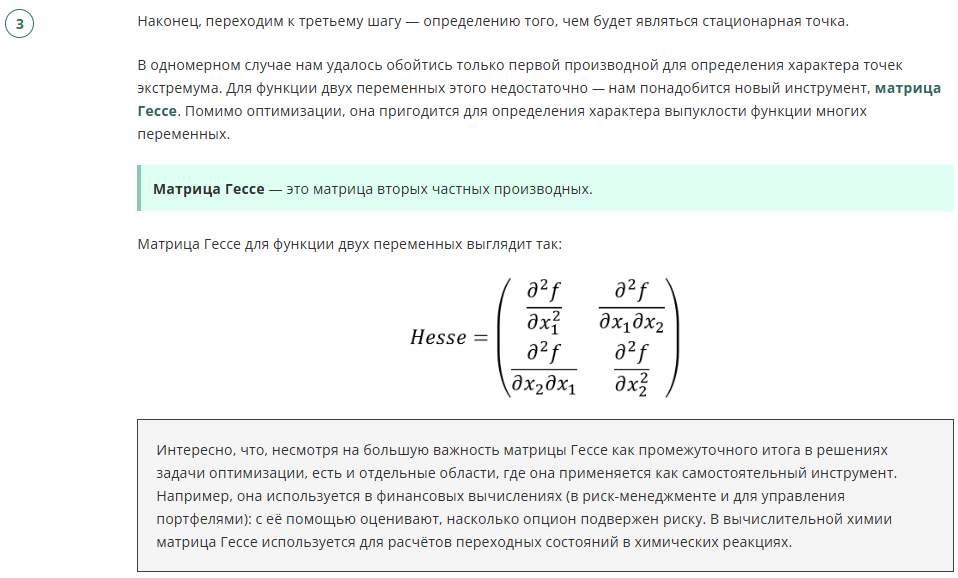

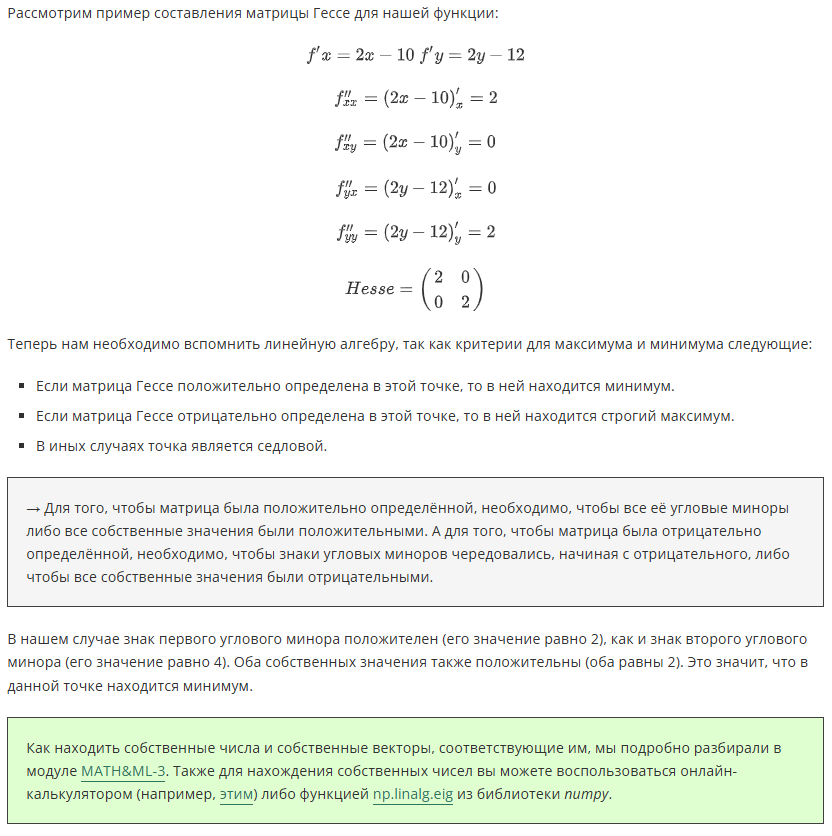

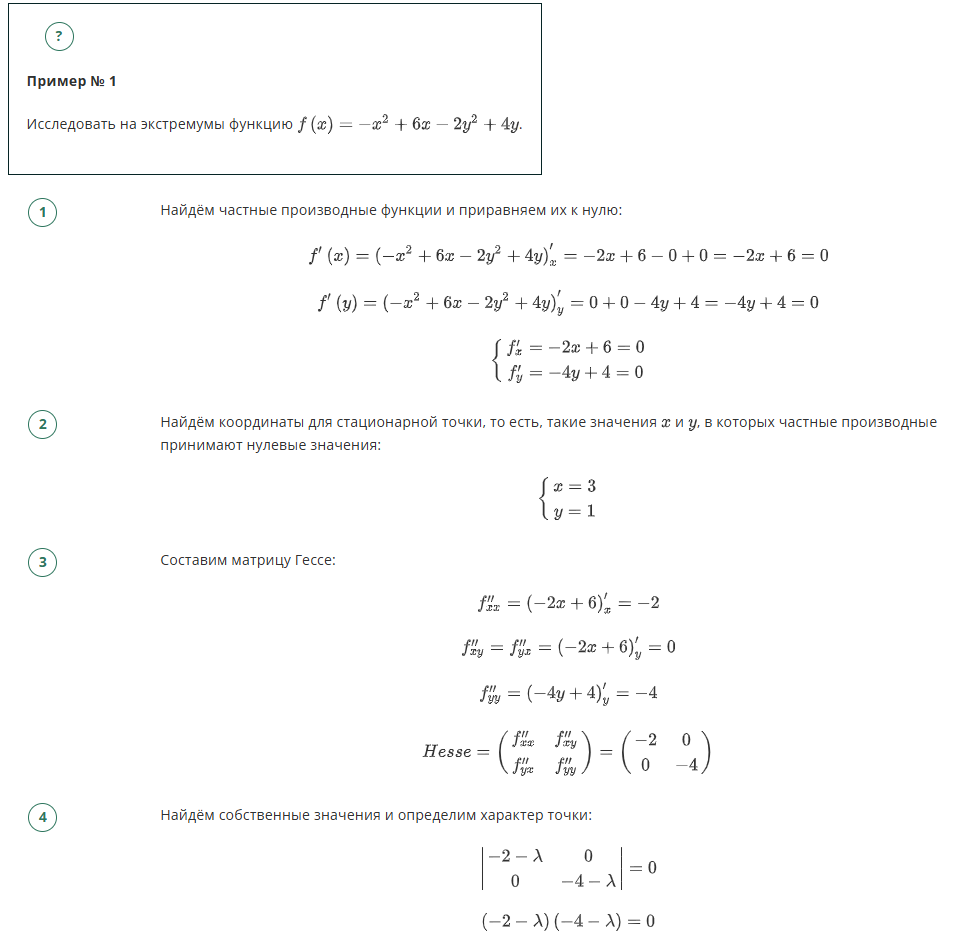

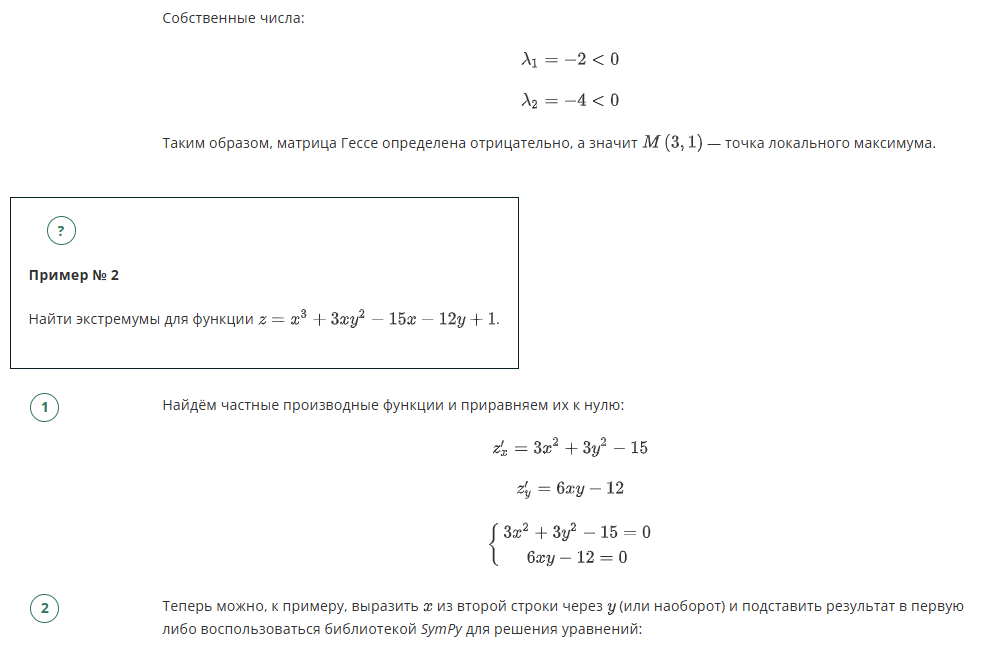

In [12]:
from sympy import *
 
x, y = symbols('x, y')
eq1 = Eq(3*x**2+3*y**2-15,0)
eq2 = Eq(6*x*y-12, 0)
 
sol = solve([eq1, eq2], [x, y])
sol

[(-2, -1), (-1, -2), (1, 2), (2, 1)]

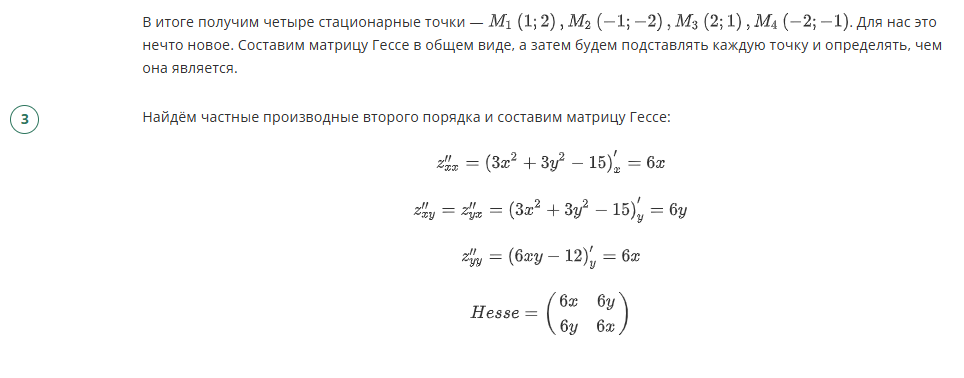

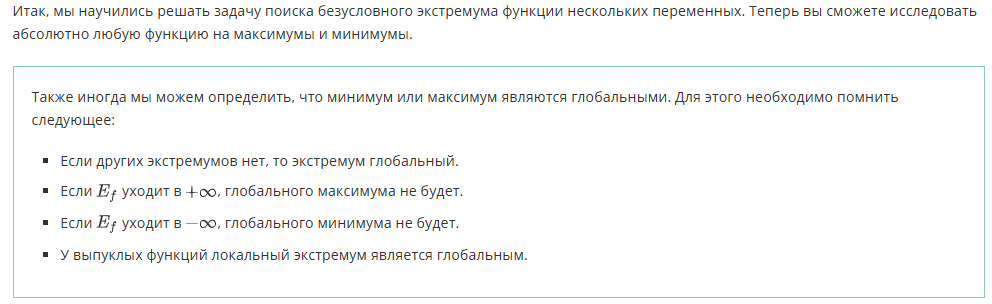

---

>**Оптимизация функций** — это задача нахождения набора входных данных целевой функции (то есть её аргументов), которые приводят к минимуму или максимуму функции.

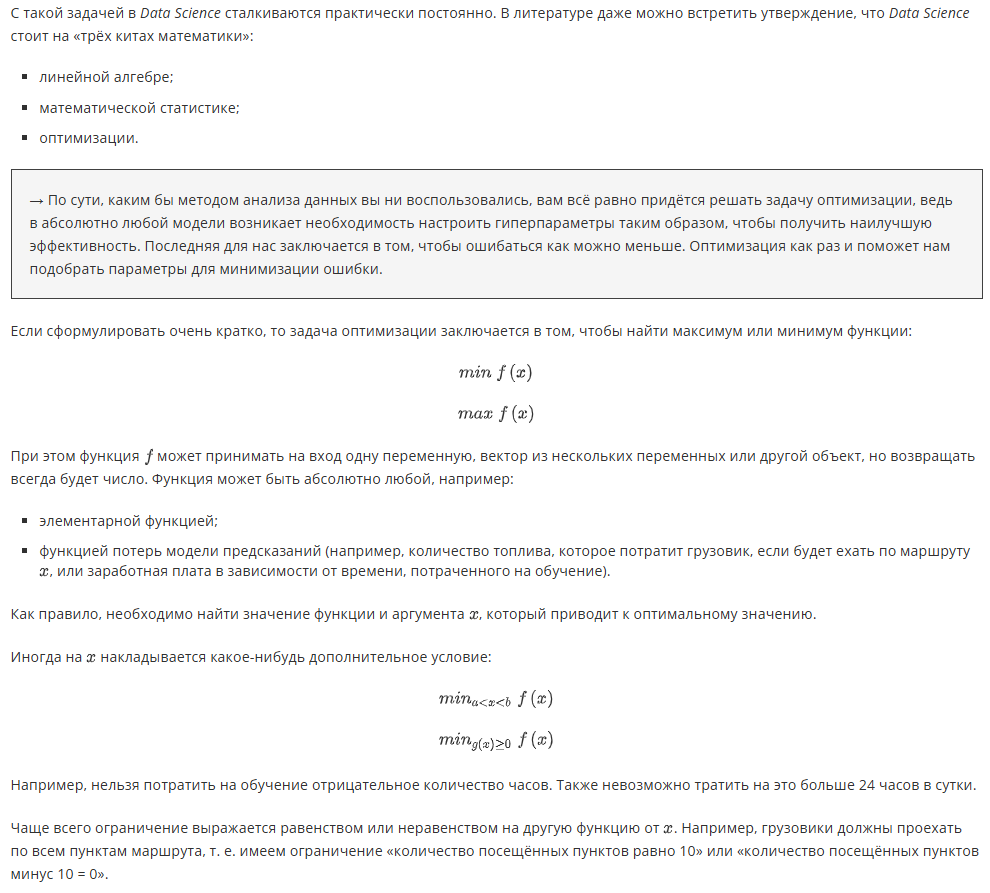

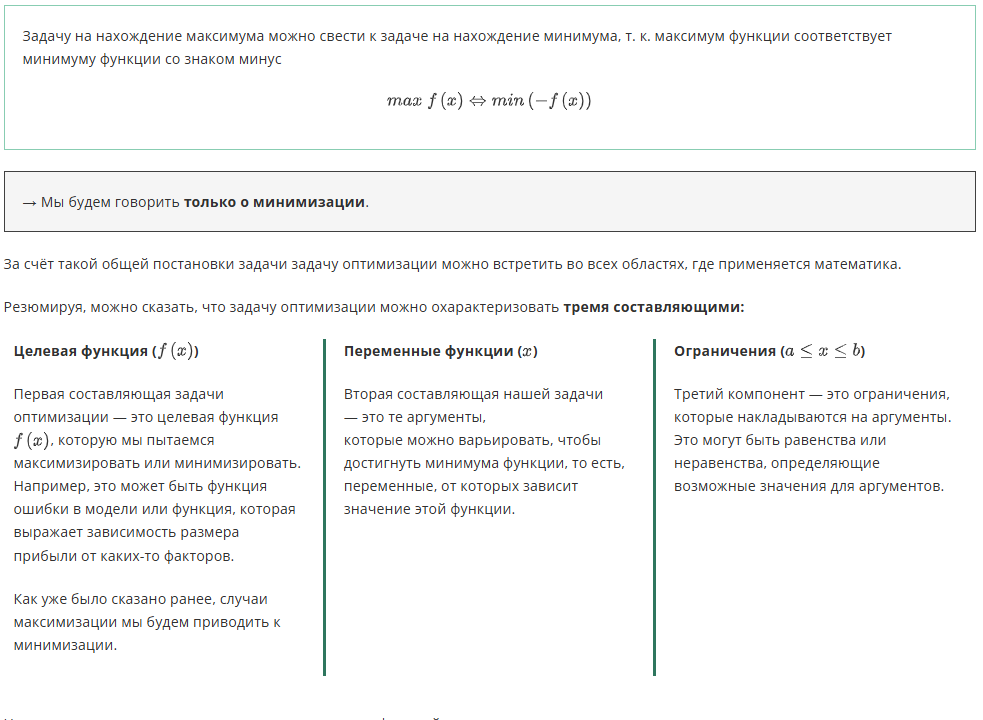

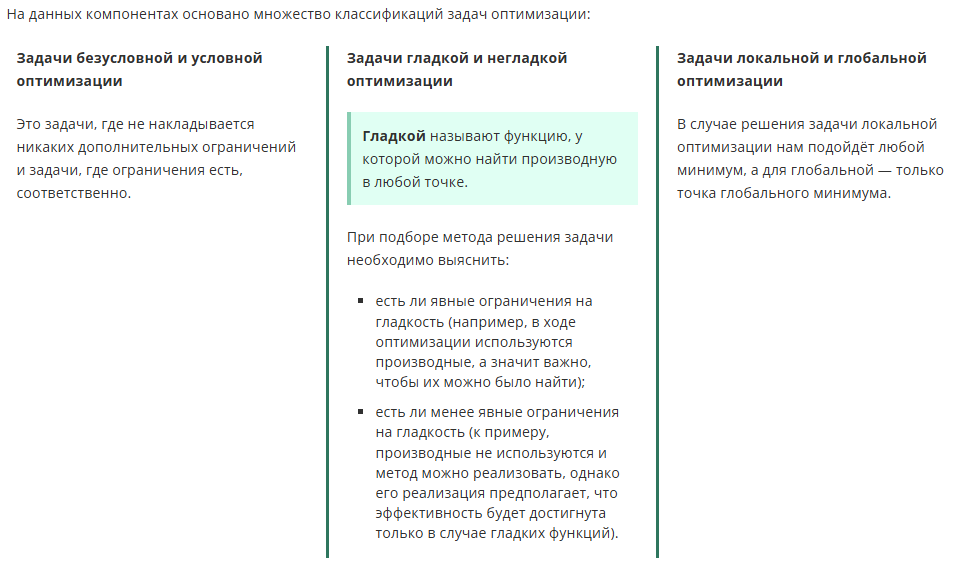

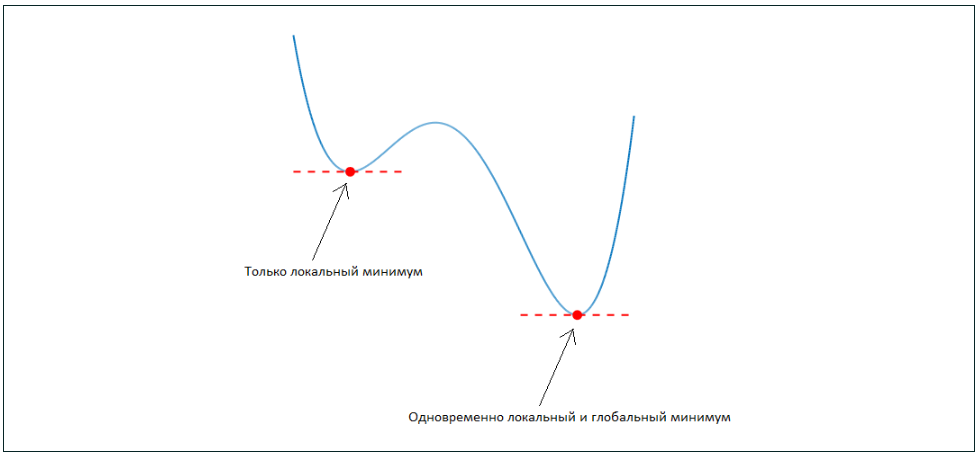

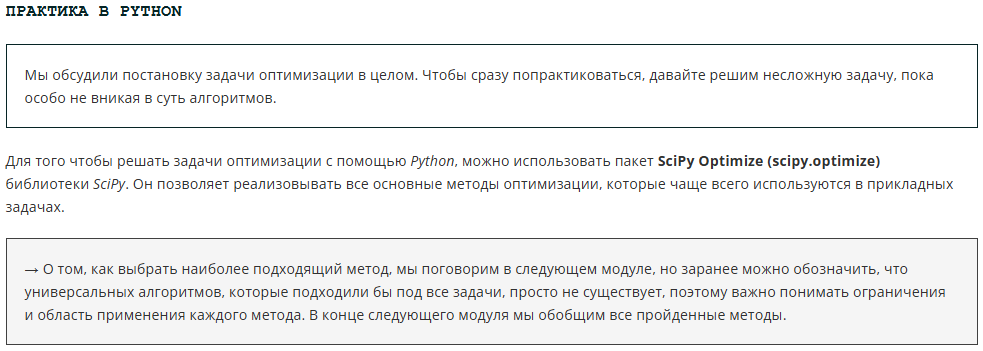

Чтобы реализовать метод оптимизации, нужна функция, для которой его будут применять. Мы возьмём самую известную функцию, используемую для таких целей — [функцию Розенброка](https://ru.wikipedia.org/wiki/Функция_Розенброка). Данную функцию можно представить так:

$$ f(x)=\sum_{i=1}^{N-1}[100(x_{i+1}-x_i^2)^2+(1-x_i)^2]$$

>Функция Розенброка, или, как её ещё называют, **функция банана** или **функция долины**, является популярной тестовой задачей для алгоритмов оптимизации на основе градиента. Вы встретитесь с ней ещё не раз, так как её часто используют в качестве эталонного теста для оценки методов оптимизации. Интересно, что придумана она была в 1960 году, то есть уже более 60 лет её используют подобным образом. Мы берём именно эту функцию, потому что она оптимальна для проверки качества алгоритмов.

Глобальный минимум  этой функции находится внутри вытянутой плоской долины (отсюда и альтернативное название функции), которая по форме напоминает параболу. Найти долину легко, чего не скажешь о глобальном минимуме для этой функции.

Давайте определим данную функцию:

In [13]:
import numpy as np
 
def func_rosen(x):
    r = np.sum(100*(x[1:]-x[:-1]**2)**2 + (1-x[:-1])**2, axis=0)
    return r

Чтобы лучше понять, что из себя представляет данная функция, изобразим её график для случая двух переменных (тогда у нас будет три измерения, и график будет в 3D). В целом, можно было бы взять и большее количество переменных — несомненный плюс этой функции как раз и состоит в возможности использовать многомерные случаи любых размерностей. Однако случай для двух аргументов будет легко представить визуально.

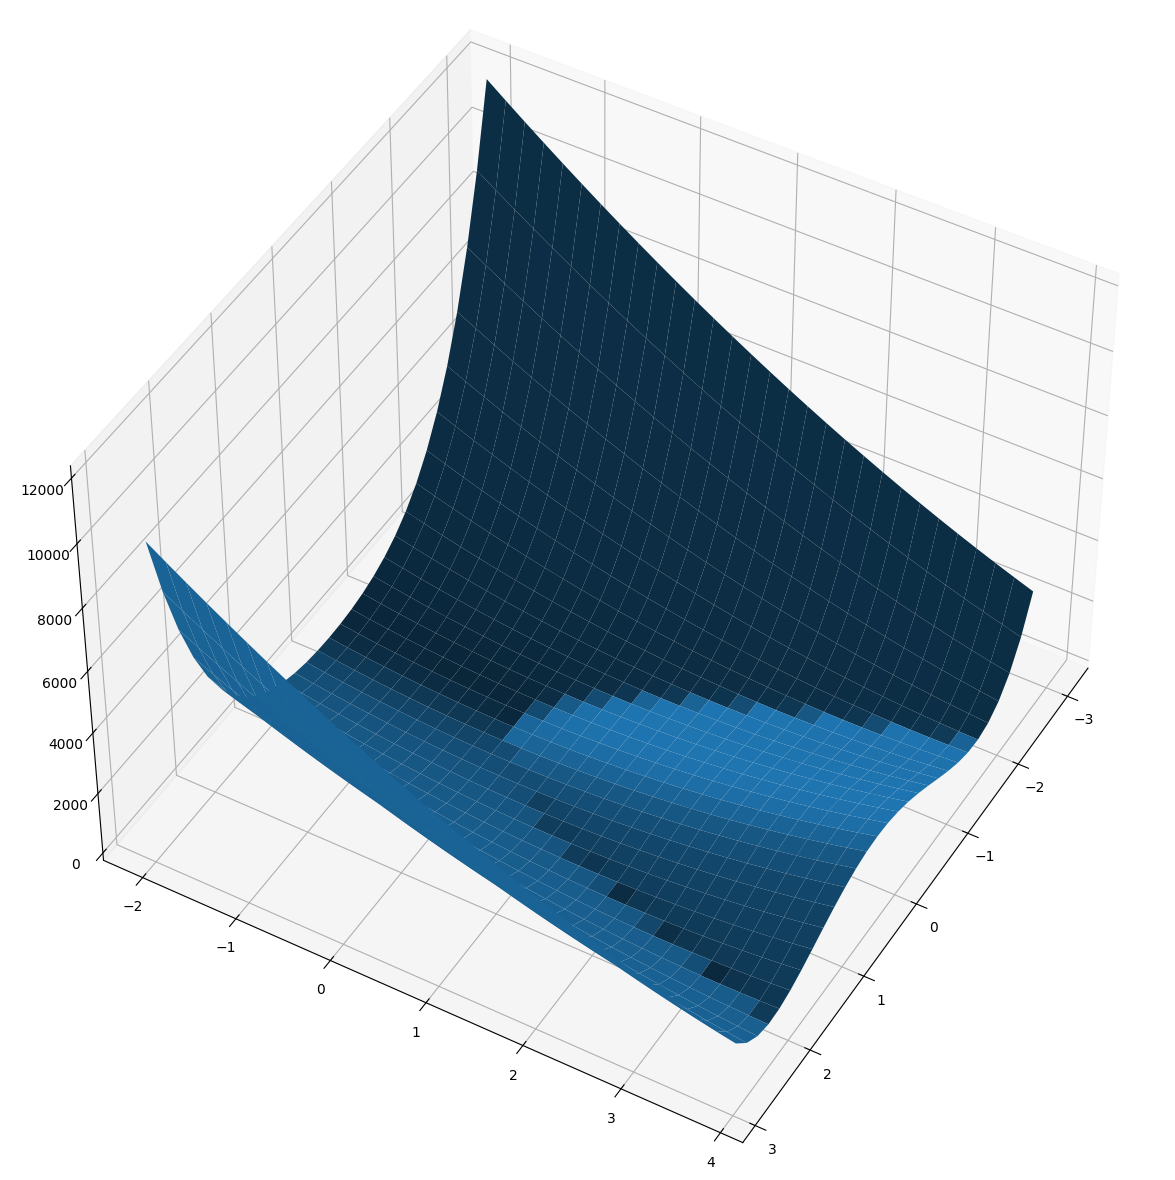

In [14]:
import matplotlib.pyplot as plt
graph = plt.figure(figsize=[25, 15])
ax = graph.add_subplot(projection='3d')
ax.view_init(45, 30)
x1 = np.arange(-3, 3, 0.2)
x2 = np.arange(-2, 4, 0.2)
x1, x2 = np.meshgrid(x1, x2)
y = func_rosen(np.array([x1,x2]))
surf = ax.plot_surface(x1, x2, y)
plt.show()

Если внимательно посмотреть на график, можно увидеть долину параболической формы, о которой мы говорили ранее.

Теперь, когда нам доступно визуальное представление функции, давайте попробуем её оптимизировать. Начнём с простых методов.

Алгоритмом оптимизации, в котором вычисляются только значения функций, является [метод Пауэлла](https://en.wikipedia.org/wiki/Powell's_method). Чтобы использовать его, необходимо установить ```method = 'powell'``` в функции ```minim```.

In [15]:
from scipy.optimize import minimize
x1 = np.array([2.4, 1.5, 2.1, 0.7, 1.1])
result_point = minimize(func_rosen, x1, method='powell')
print(result_point.x)

[1. 1. 1. 1. 1.]


Итак, мы нашли точку минимума одним из методов. Теперь давайте используем для этого другой алгоритм.

Допустим, у нас есть некоторая точка $x_0$ в пятимерном пространстве. Найдём ближайшую к ней точку минимума функции Розенброка, используя алгоритм [метода Нелдера — Мида](https://ru.wikipedia.org/wiki/Метод_Нелдера_—_Мида) (также его называют **симплекс-методом**):

In [16]:
from scipy.optimize import minimize
x1 = np.array([2.4, 1.5, 2.1, 0.7, 1.1])
result_point = minimize(func_rosen, x1, method='nelder-mead')
print(result_point.x)

[1.02760651 1.05589639 1.11509457 1.2440091  1.54862169]


Симплекс-метод является стандартным методом для решения задачи оптимизации, в которой есть функция и несколько ограничений, выраженных в виде неравенств. Неравенства определяют область в форме многоугольника, в одной из вершин которого обычно находится решение. Симплекс-метод представляет собой систематическую процедуру проверки вершин как возможных решений.

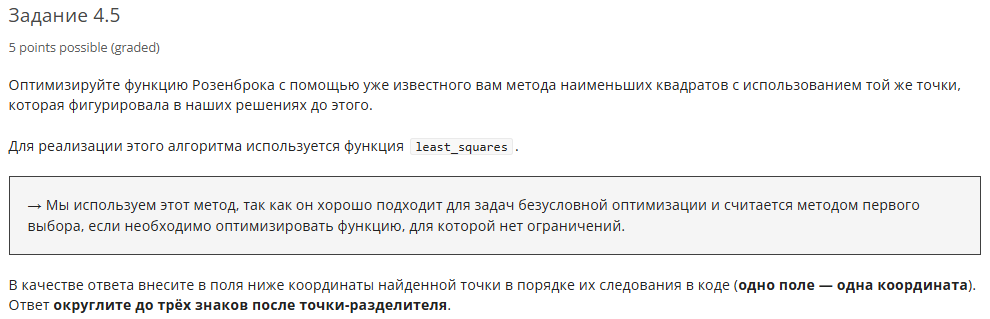

In [18]:
import numpy as np
def func_rosen(x):
    r = np.sum(100*(x[1:]-x[:-1]**2)**2 + (1-x[:-1])**2, axis=0)
    return r
 
 
from scipy.optimize import least_squares
x1 = np.array([2.4, 1.5, 2.1, 0.7, 1.1])
res =  least_squares(func_rosen, x1)
print(res.x.round(3))

[0.939 0.882 0.776 0.603 0.361]


---

# Условные экстремумы. Метод Лагранжа

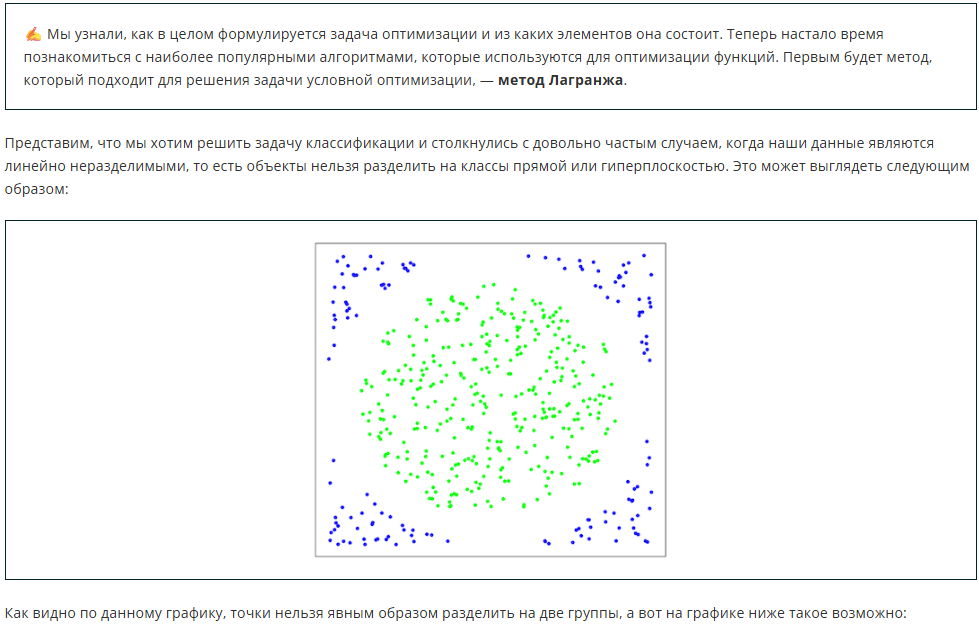

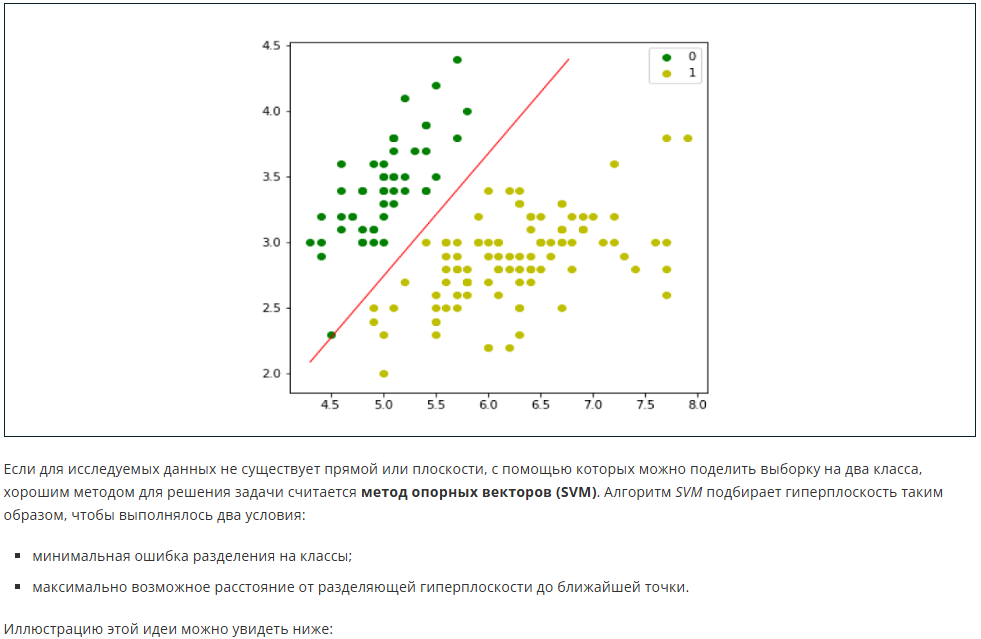

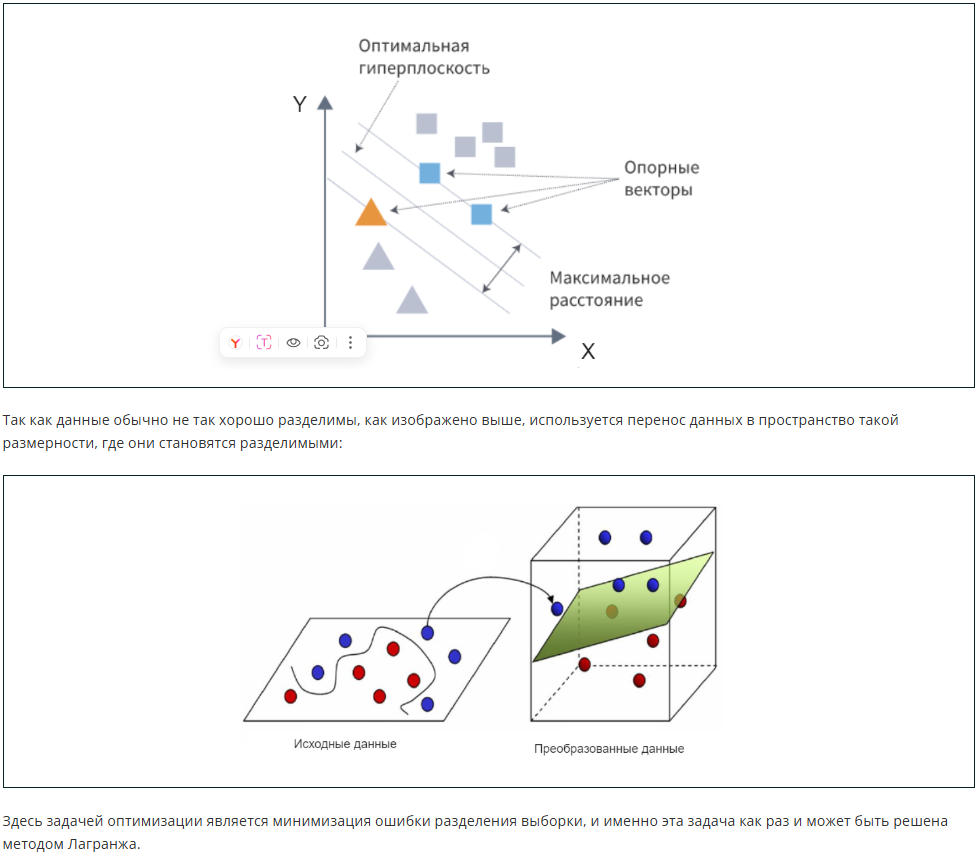

>**Метод множителей Лагранжа** является стратегией обнаружения минимумов и максимумов дифференцируемых функций (то есть таких функций, для которых можно найти производную) при условии ограничений равенства на его независимые переменные.

В случае безусловной оптимизации мы решали задачи, приравнивая к нулю производную функции одной переменной или все частные производные в многомерном случае. Далее мы находили экстремумы и выбирали минимум или максимум. В случае с поиском решения задачи условной оптимизации алгоритм будет похож, но в него будут внесены некоторые коррективы.

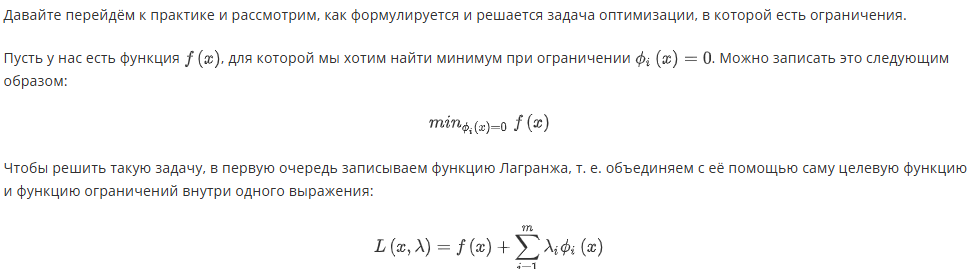

>Дополнительные переменные $\lambda_i$, которые появляются при формулировании функции Лагранжа, называются **множителями Лагранжа**.

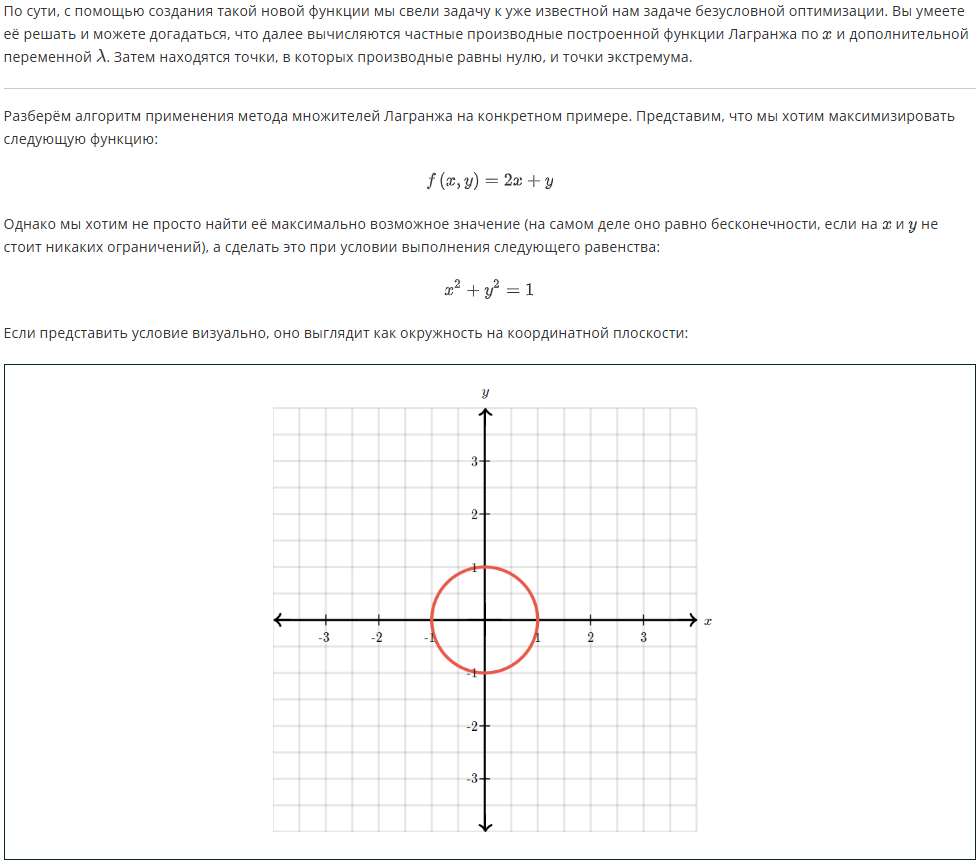

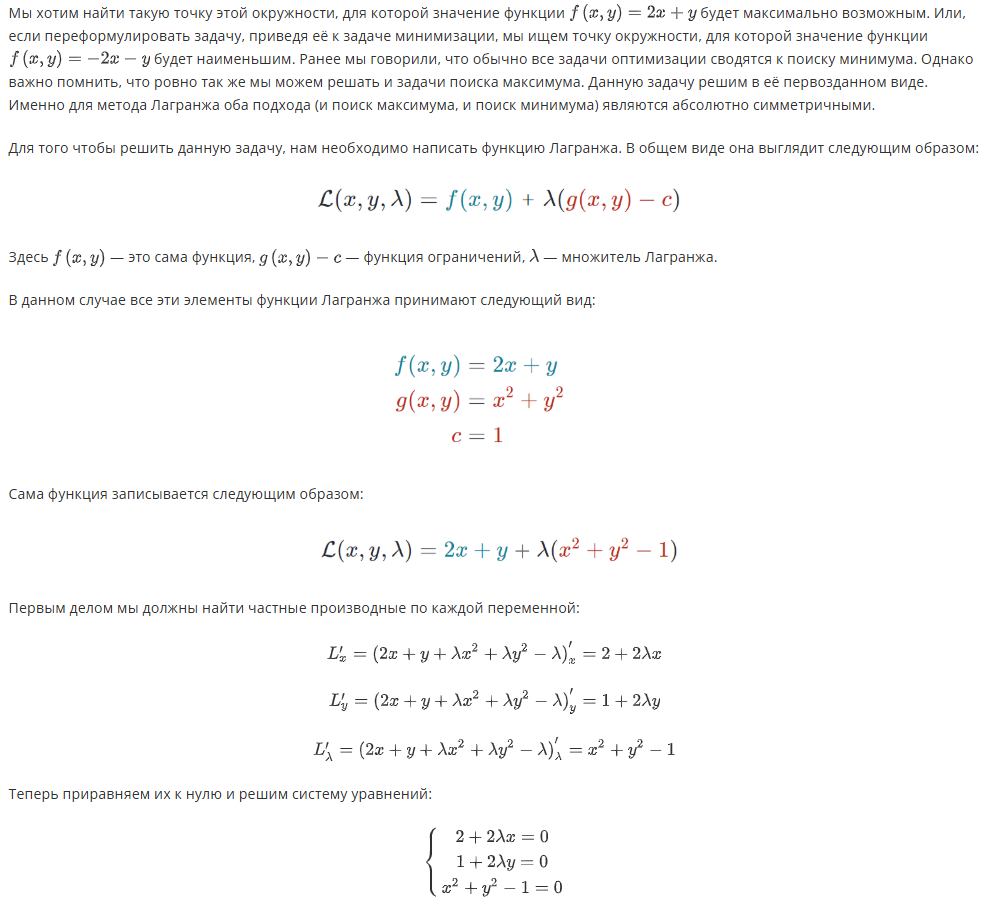

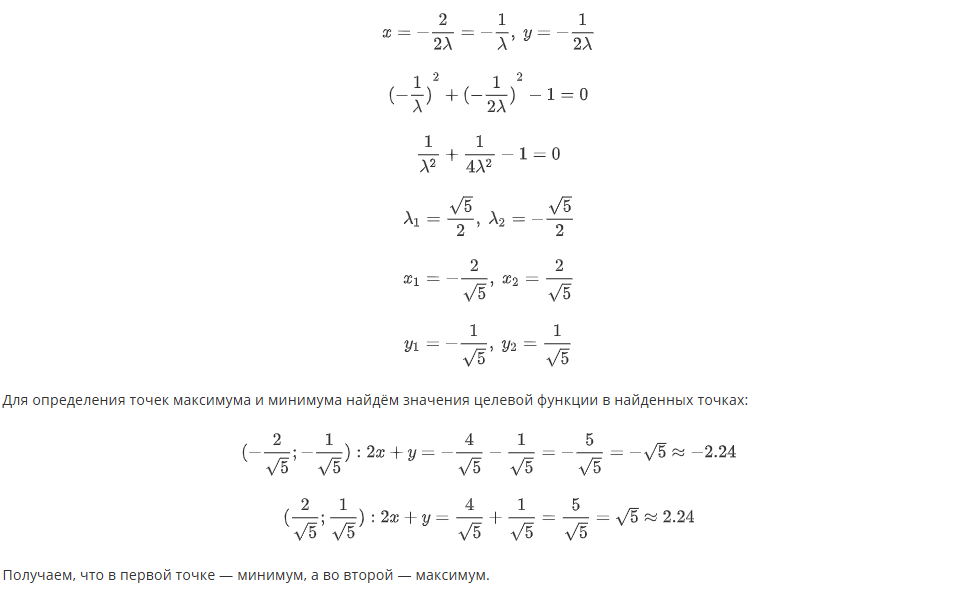

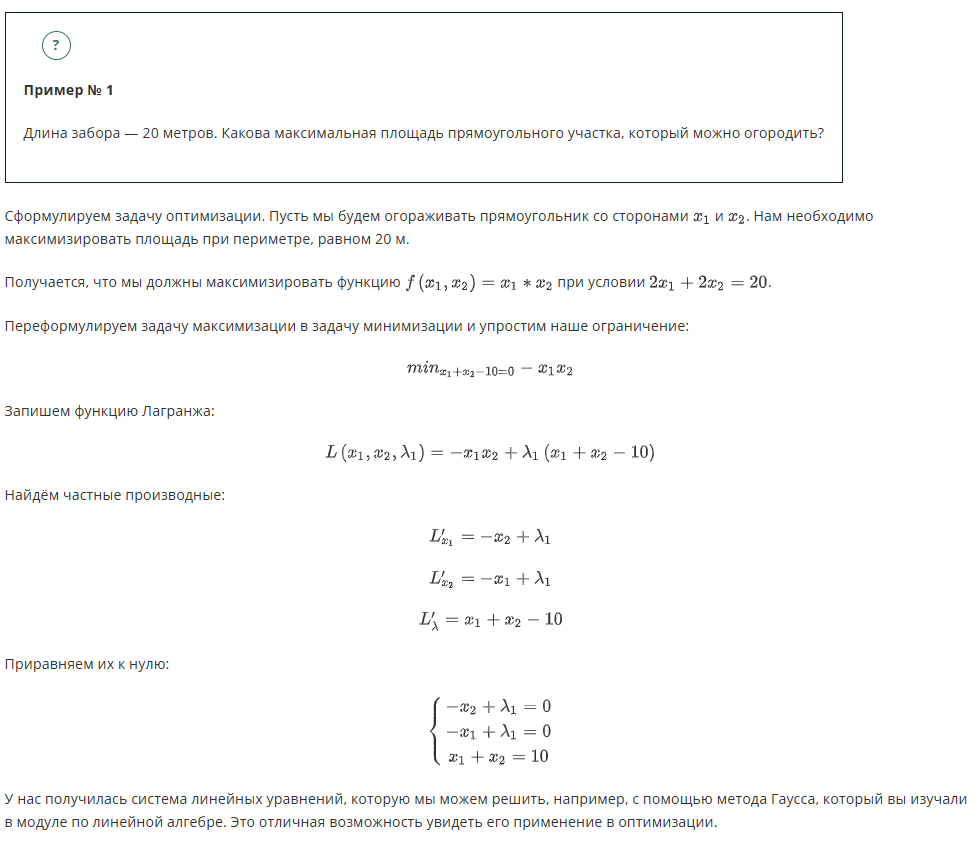

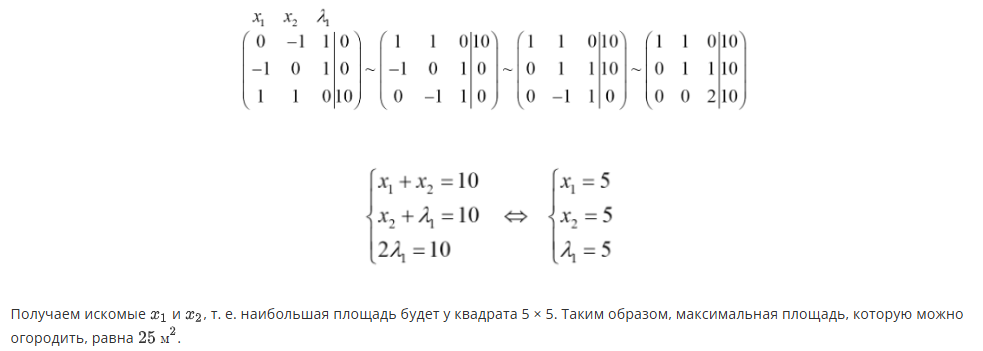

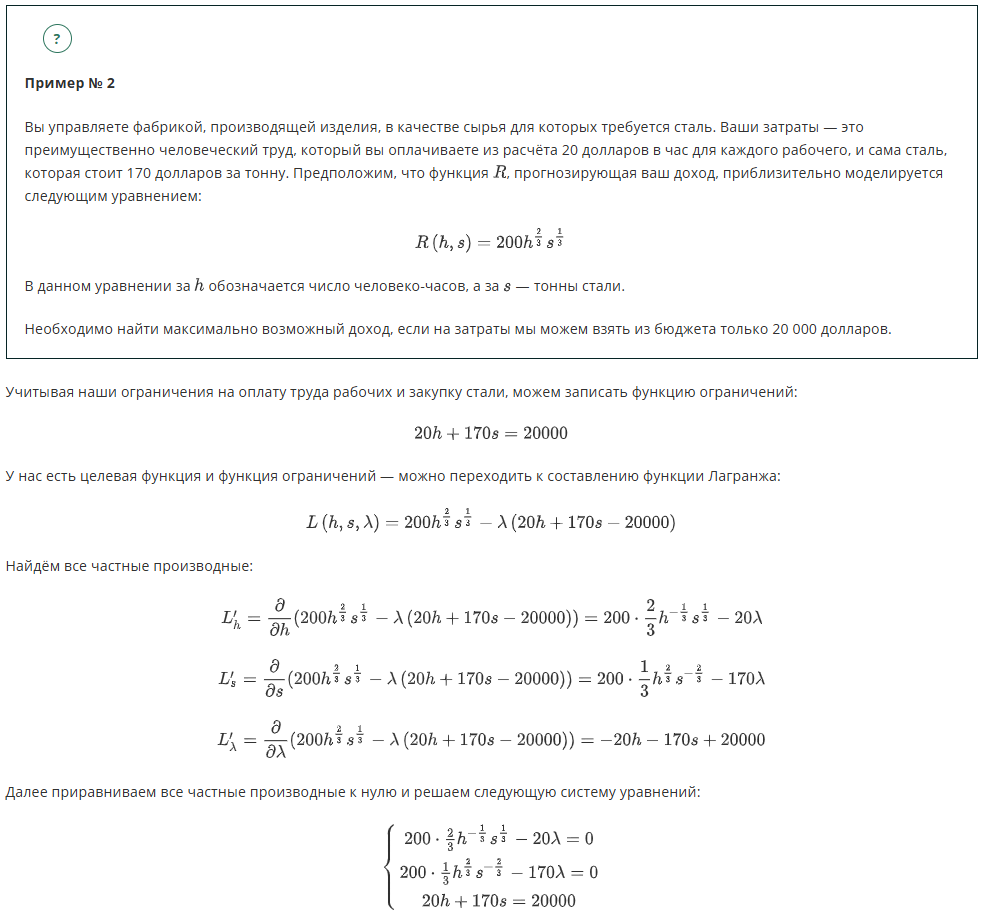

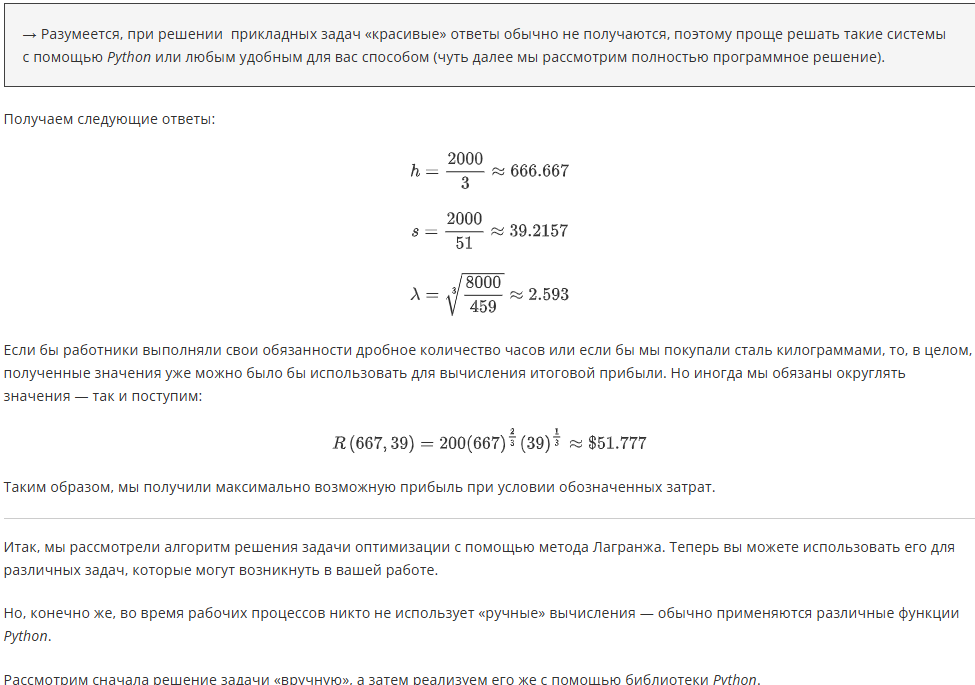

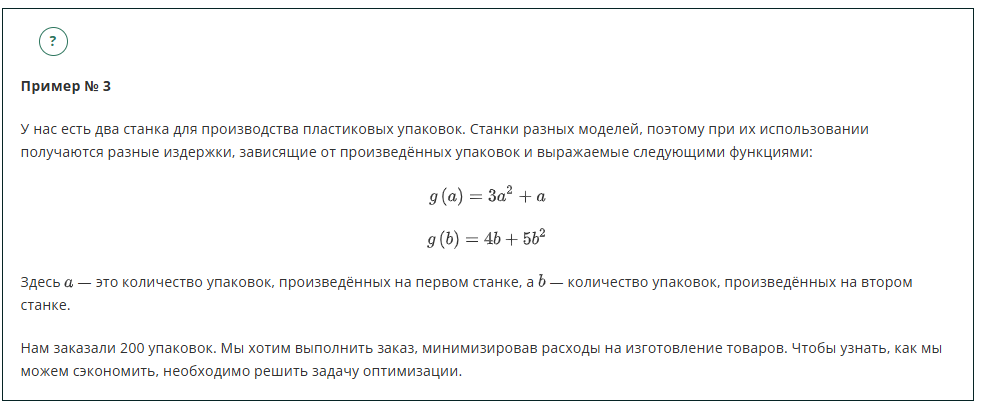

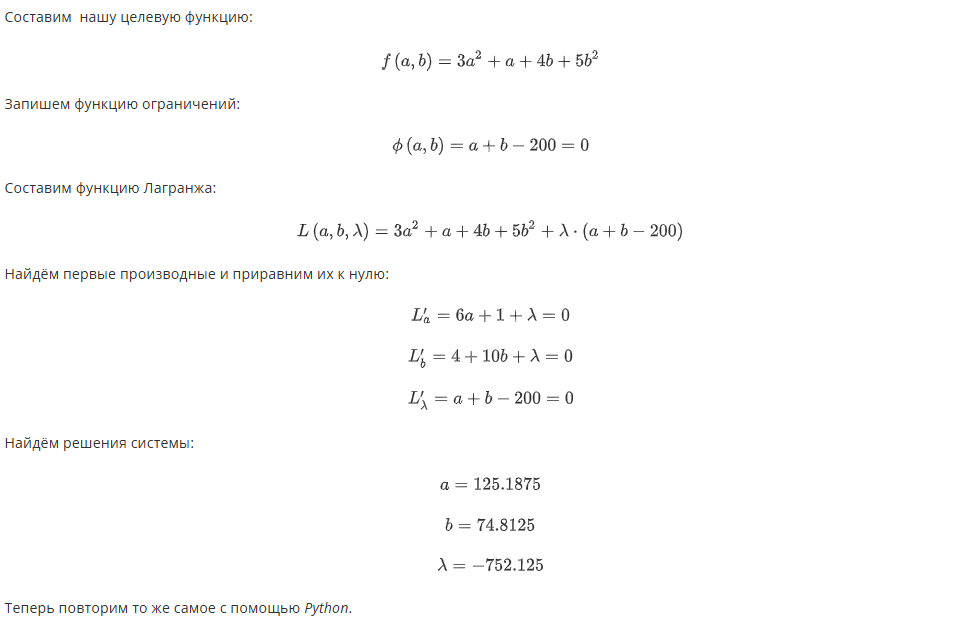

In [24]:
from sympy import *
a,b,w=symbols('a b w' )
g = 3*a**2 + a + 4*b + 5*b**2
print('Целевая функция для аргументов a и b :\n f = ', g)
q = a + b - 200
print('Функция ограничений: ', q,'= 0')
f = 3*a**2 + a + 4*b + 5*b**2 + w*(a + b - 200)
print('Функция Лагранжа :\n ',f)
fa = f.diff(a)
print('df/da =',fa,'= 0')
fb = f.diff(b)
print('df/db =',fb,'= 0')
fw = f.diff(w)
print('df/dw =',fw,'= 0')
sols = solve([fa,fb,fw],a,b,w)
print('Стационарная точка M(x,y):\n',float(sols[a]),',',float(sols[b]))

Целевая функция для аргументов a и b :
 f =  3*a**2 + a + 5*b**2 + 4*b
Функция ограничений:  a + b - 200 = 0
Функция Лагранжа :
  3*a**2 + a + 5*b**2 + 4*b + w*(a + b - 200)
df/da = 6*a + w + 1 = 0
df/db = 10*b + w + 4 = 0
df/dw = a + b - 200 = 0
Стационарная точка M(x,y):
 125.1875 , 74.8125


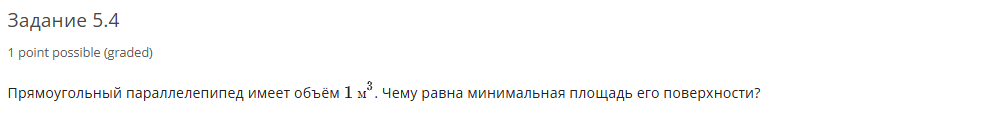

In [39]:
from sympy import *
a,b,c,w=symbols('a b c w' )
g = 2*a*b + 2*b*c + 2*a*c
print('Целевая функция для площади поверхности куба :\n f = ', g)
q = a*b*c - 1
print('Функция ограничений: ', q,'= 0')
f = 2*a*b + 2*b*c + 2*a*c + w*(a*b*c - 1)
print('Функция Лагранжа :\n ',f)
fa = f.diff(a)
print('df/da =',fa,'= 0')
fb = f.diff(b)
print('df/db =',fb,'= 0')
fc = f.diff(c)
print('df/dc =',fc,'= 0')
fw = f.diff(w)
print('df/dw =',fw,'= 0')
solutions_list = solve([fa, fb, fc, fw], (a, b, c, w), dict=True)
sol_dict = solutions_list[0]

    # Получаем численные значения через .evalf()
a_val = sol_dict[a].evalf()
b_val = sol_dict[b].evalf()
c_val = sol_dict[c].evalf()
print('Стационарная точка M(x,y,z):\n',float(a_val),',',float(b_val),',',float(c_val))
s_min = 2*a_val*b_val + 2*b_val*c_val + 2*a_val*c_val
print('Минимальная площадь поверхности куба равна - ',round(s_min))

Целевая функция для площади поверхности куба :
 f =  2*a*b + 2*a*c + 2*b*c
Функция ограничений:  a*b*c - 1 = 0
Функция Лагранжа :
  2*a*b + 2*a*c + 2*b*c + w*(a*b*c - 1)
df/da = b*c*w + 2*b + 2*c = 0
df/db = a*c*w + 2*a + 2*c = 0
df/dc = a*b*w + 2*a + 2*b = 0
df/dw = a*b*c - 1 = 0
Стационарная точка M(x,y,z):
 1.0 , 1.0 , 1.0
Минимальная площадь поверхности куба равна -  6


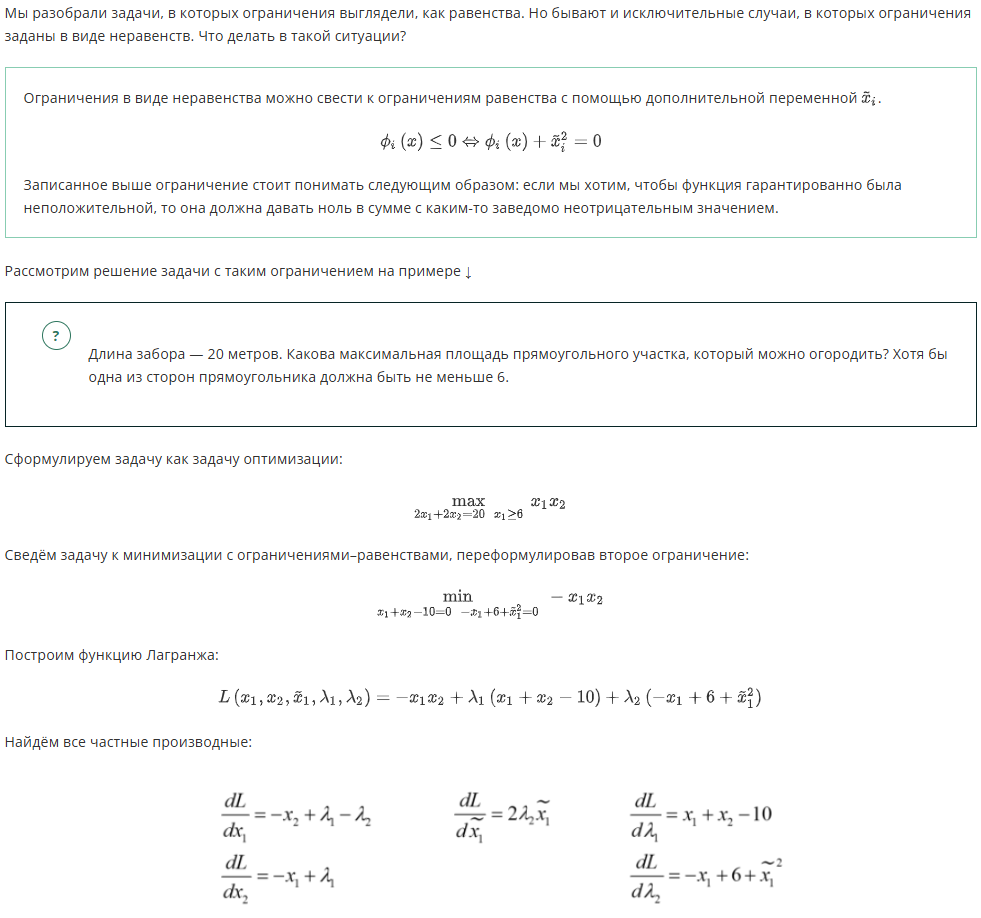

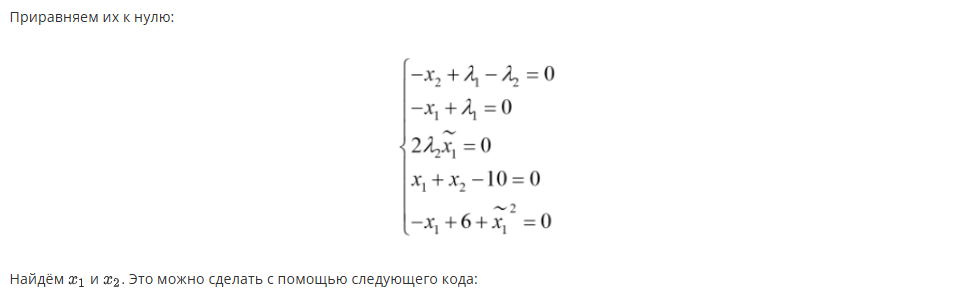

In [40]:
# Импортируем все необходимые функции из библиотеки SymPy
from sympy import init_printing, solve, symbols

# Подключаем аккуратный вывод формул
init_printing()

# Создаём переменные
x1, x2, x1_tilde, lambda1, lambda2 = symbols(
    "x_1 x_2 xtilde_2 \lambda_1 \lambda_2", real=True
)

# Пишем систему уравнений для переменных
dLdx1 = -x2 + lambda1 - lambda2
dLdx2 = -x1 + lambda1
dLdx1_tilde = 2 * lambda2 * x1_tilde
dLdlambda1 = x1 + x2 - 10
dLdlambda2 = -x1 + 6 + x1_tilde**2

# Решаем систему уравнений с помощью функции solve
solution = solve(
    [dLdx1, dLdx2, dLdx1_tilde, dLdlambda1, dLdlambda2],
    x1,
    x2,
    x1_tilde,
    lambda1,
    lambda2,
)

print(solution)

[(6, 4, 0, 6, 2)]


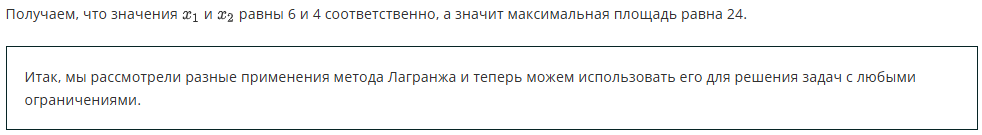

---